# Learning Rate modelling

In [1]:
# @title Imports
import sys
import os
# Get the absolute path of the RL_task directory
sys.path.append(os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pathlib as Path
import io
import analysis_functions
import helpers
import ipywidgets as widgets  # interactive display
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logit, expit
from scipy.optimize import minimize
import seaborn as sns
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [2]:
# Usage for a file
base_dir = r'/project/3025011.01/data/' # \\fileserver.dccn.nl\project\3025011.01\data r'C:\Users\marti\git\RL_task\experiment_output\behavioural_files'
file_name = r'sub-18/ses-03/rl/sub-18_d3_rlt_behavioural_output.csv' # r'sub-55_rlt_behavioural_output.csv'

# We want to plot a single participant's learning curve
helpers.process_stimuli_file(base_dir, file_name)

(array([  8,  72, 128, 140, 152, 168, 188, 200, 220, 284, 340, 360, 376,
        392, 404, 424, 440]),
 array([64, 56, 12, 12, 16, 20, 12, 20, 64, 56, 20, 16, 16, 12, 20, 16]))

In [3]:
# Smoothing function
def smooth(y, box_pts):
    box = np.ones(box_pts) / box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


# Plotting function
def plot_sequence(df):
    # Map stimuli_type to labels and colors
    stimuli_labels = {1: "Angry", 3: "Happy"}
    stimuli_colors = {1: "red", 3: "blue"}
    
    # Only keep the first 205 rows
    #df = df.iloc[:224].copy()
    
    df['stimuli_label'] = df['stimuli_type'].map(stimuli_labels)
    df['color'] = df['stimuli_type'].map(stimuli_colors)

    # Extract subject ID from dataframe
    subject_id = df['subject_id'].iloc[0]
    
    fig, ax = plt.subplots(figsize=(15, 10))
    
    for stim_type in df['stimuli_type'].unique():
        if stim_type not in stimuli_labels:
            continue
        
        stim_df = df[df['stimuli_type'] == stim_type].copy()
        x = stim_df.index
        y_prob = stim_df['probability_condition']
        label = stimuli_labels[stim_type]
        color = stimuli_colors[stim_type]

        # Plot raw contingency curve
        ax.plot(x, y_prob, label=label + " (p(reward|up))", color=color, linestyle='-')

    ax.set_xlabel("Trial Index")
    ax.set_ylabel("Response / p(Reward|Up)")
    ax.set_title(f"{subject_id} Response-Outcome Contingency with Smoothed Choices")
    ax.legend()
    plt.show()

# Plotting function
def plot_response_outcome(df):
    # Map stimuli_type to labels and colors
    stimuli_labels = {1: "Angry", 3: "Happy"}
    stimuli_colors = {1: "red", 3: "blue"}
    
    df['stimuli_label'] = df['stimuli_type'].map(stimuli_labels)
    df['color'] = df['stimuli_type'].map(stimuli_colors)

    # Extract subject ID from dataframe
    subject_id = df['subject_id'].iloc[0]
    
    fig, ax = plt.subplots(figsize=(25, 15))
    
    for stim_type in df['stimuli_type'].unique():
        if stim_type not in stimuli_labels:
            continue
        
        stim_df = df[df['stimuli_type'] == stim_type].copy()
        x = stim_df.index
        y_prob = stim_df['probability_condition']
        label = stimuli_labels[stim_type]
        color = stimuli_colors[stim_type]

        # Plot raw contingency curve
        ax.plot(x, y_prob, label=label + " (p(reward|up))", color=color, linestyle='-')

        # Plot individual responses
        for idx, row in stim_df.iterrows():
            if row['response'] == 'up':
                ax.scatter(idx, 100, color=row['color'], marker='.', s=100, label='_nolegend_')
            elif row['response'] == 'down':
                ax.scatter(idx, 0, color=row['color'], marker='.', s=100, label='_nolegend_')

        # Binary response: 1 for 'up', 0 for 'down'
        stim_df['choice_binary'] = (stim_df['response'] == 'up').astype(int)

        # Rolling average of choices (smoothed behavior)
        stim_df['choice_smooth'] = stim_df['choice_binary'].rolling(window=5, center=False, min_periods=1).mean() * 100

        # Plot smoothed choice curve
        ax.plot(x, stim_df['choice_smooth'], linestyle='--', color=color, label=label + " (choice avg)")

    ax.set_xlabel("Trial Index")
    ax.set_ylabel("Response / p(Reward|Up)")
    ax.set_title(f"{subject_id} Response-Outcome Contingency with Smoothed Choices")
    ax.legend()
    plt.show()

# Plotting function with split subplots for Angry and Happy
def save_response_2outcome(df, save_path):
    # Map stimuli_type to labels and colors
    stimuli_labels = {1: "Angry", 3: "Happy"}
    stimuli_colors = {1: "red", 3: "blue"}

    df['stimuli_label'] = df['stimuli_type'].map(stimuli_labels)
    df['color'] = df['stimuli_type'].map(stimuli_colors)

    # Extract subject ID from dataframe
    subject_id = df['subject_id'].iloc[0]

    # Create two subplots (1 row for Happy, 1 row for Angry)
    fig, axes = plt.subplots(nrows=2, figsize=(15, 10), sharex=True)

    for i, stim_type in enumerate([3, 1]):  # Top = Happy (3), Bottom = Angry (1)
        ax = axes[i]
        
        if stim_type not in stimuli_labels:
            continue

        stim_df = df[df['stimuli_type'] == stim_type].copy()
        x = stim_df.index
        y_prob = stim_df['probability_condition']
        label = stimuli_labels[stim_type]
        color = stimuli_colors[stim_type]

        # Plot raw contingency curve
        ax.plot(x, y_prob, label="p(reward|up)", color=color, linestyle='-')

        # Plot individual responses
        for idx, row in stim_df.iterrows():
            if row['response'] == 'up':
                ax.scatter(idx, 100, color=row['color'], marker='.', s=100, label='_nolegend_')
            elif row['response'] == 'down':
                ax.scatter(idx, 0, color=row['color'], marker='.', s=100, label='_nolegend_')

        # Binary response: 1 for 'up', 0 for 'down'
        stim_df['choice_binary'] = (stim_df['response'] == 'up').astype(int)
        #print(stim_df['choice_binary'])

        # Rolling average of choices
        stim_df['choice_smooth'] = stim_df['choice_binary'].rolling(window=5, center=False, min_periods=1).mean() * 100

        # Plot smoothed choice curve
        ax.plot(x, stim_df['choice_smooth'], linestyle='--', color=color, label="Smoothed choice")

        # Axis labels and title
        ax.set_ylabel("Response / p(Reward|Up)")
        ax.set_title(f"{label} History")

        ax.legend()

    axes[1].set_xlabel("Trial Index")
    fig.suptitle(f"{subject_id}: Response-Outcome Contingency Split by Emotion", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

def plot_response_2outcome(df):
    # Map labels and colors
    stimuli_labels = {1: "Angry", 3: "Happy"}
    line_colors = {1: "green", 3: "red"}
    dot_colors = {1: "green", 3: "red"}

    df['stimuli_label'] = df['stimuli_type'].map(stimuli_labels)
    df['line_color'] = df['stimuli_type'].map(line_colors)
    df['dot_color'] = df['stimuli_type'].map(dot_colors)

    subject_id = df['subject_id'].iloc[0]

    # Step 1: Plot only raw contingency curve
    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]
        stim_df = df[df['stimuli_type'] == stim_type]
        x = stim_df.index
        y = stim_df['probability_condition']
        label = stimuli_labels[stim_type]
        color = line_colors[stim_type]
        ax.plot(x, y, label="p(reward|up)", color=color)
        ax.set_title(f"{label} Contingency")
        ax.set_ylabel("p(Reward|Up)")
        ax.legend()
    axes[1].set_xlabel("Trial Index")
    fig.suptitle("Contingency Curves Only")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Step 2: Add response dots
    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]
        stim_df = df[df['stimuli_type'] == stim_type]
        x = stim_df.index
        y = stim_df['probability_condition']
        ax.plot(x, y, label="p(reward|up)", color=line_colors[stim_type])

        for idx, row in stim_df.iterrows():
            y_val = 100 if row['response'] == 'up' else 0
            ax.scatter(idx, y_val, color=row['dot_color'], s=100, marker='.', label='_nolegend_')

        label = stimuli_labels[stim_type]
        ax.set_title(f"{label} Contingency")
        ax.set_ylabel("Response / p(Reward|Up)")
        ax.legend()
    axes[1].set_xlabel("Trial Index")
    fig.suptitle("With Responses")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Step 3: Add smoothed choice curve
    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]
        stim_df = df[df['stimuli_type'] == stim_type].copy()
        x = stim_df.index
        y = stim_df['probability_condition']
        ax.plot(x, y, label="p(reward|up)", color=line_colors[stim_type])

        for idx, row in stim_df.iterrows():
            y_val = 100 if row['response'] == 'up' else 0
            ax.scatter(idx, y_val, color=row['dot_color'], s=100, marker='.', label='_nolegend_')

        # Compute and plot smoothed choice
        stim_df['choice_binary'] = (stim_df['response'] == 'up').astype(int)
        stim_df['choice_smooth'] = stim_df['choice_binary'].rolling(window=5, min_periods=1).mean() * 100
        ax.plot(x, stim_df['choice_smooth'], linestyle='--', color=line_colors[stim_type], label="Smoothed choice")

        label = stimuli_labels[stim_type]
        ax.set_title(f"{label} Contingency")
        ax.set_ylabel("Response / p(Reward|Up)")
        ax.legend()
    axes[1].set_xlabel("Trial Index")
    fig.suptitle("Smoothed Choice Curve")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_simulation_response_2outcome(all_simulations_df, subject, model):
    # Filter data
    df = all_simulations_df[(all_simulations_df['subject'] == subject) & (all_simulations_df['model'] == model)].copy()
    
    if df.empty:
        print(f"No data found for subject {subject} and model {model}")
        return

    # Map labels and colors
    stimuli_labels = {1: "Angry", 3: "Happy"}
    line_colors = {1: "green", 3: "red"}
    dot_colors = {1: "green", 3: "red"}

    df['stimuli_label'] = df['stimuli_type'].map(stimuli_labels)
    df['line_color'] = df['stimuli_type'].map(line_colors)
    df['dot_color'] = df['stimuli_type'].map(dot_colors)

    # Set index to trial order if needed
    df = df.sort_values('trial').reset_index(drop=True)

    # Step 1: Contingency curve
    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]
        stim_df = df[df['stimuli_type'] == stim_type]
        x = stim_df.index
        y = stim_df['probability_condition']
        label = stimuli_labels[stim_type]
        color = line_colors[stim_type]
        ax.plot(x, y, label="p(reward|up)", color=color)
        ax.set_title(f"{label} Contingency")
        ax.set_ylabel("p(Reward|Up)")
        ax.legend()
    axes[1].set_xlabel("Trial Index")
    fig.suptitle(f"Simulated Contingency Curves — Subject {subject} | Model {model}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Step 2: Add response dots
    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]
        stim_df = df[df['stimuli_type'] == stim_type]
        x = stim_df.index
        y = stim_df['probability_condition']
        ax.plot(x, y, label="p(reward|up)", color=line_colors[stim_type])
        for idx, row in stim_df.iterrows():
            y_val = 100 if row['response'] == 'up' else 0
            ax.scatter(idx, y_val, color=row['dot_color'], s=100, marker='.', label='_nolegend_')
        ax.set_title(f"{stimuli_labels[stim_type]} Contingency")
        ax.set_ylabel("Response / p(Reward|Up)")
        ax.legend()
    axes[1].set_xlabel("Trial Index")
    fig.suptitle(f"With Responses — Subject {subject} | Model {model}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Step 3: Add smoothed choice curve
    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]
        stim_df = df[df['stimuli_type'] == stim_type].copy()
        x = stim_df.index
        y = stim_df['probability_condition']
        ax.plot(x, y, label="p(reward|up)", color=line_colors[stim_type])
        for idx, row in stim_df.iterrows():
            y_val = 100 if row['response'] == 'up' else 0
            ax.scatter(idx, y_val, color=row['dot_color'], s=100, marker='.', label='_nolegend_')
        # Smooth
        stim_df['choice_binary'] = (stim_df['response'] == 'up').astype(int)
        stim_df['choice_smooth'] = stim_df['choice_binary'].rolling(window=5, min_periods=1).mean() * 100
        ax.plot(x, stim_df['choice_smooth'], linestyle='--', color=line_colors[stim_type], label="Smoothed choice")
        ax.set_title(f"{stimuli_labels[stim_type]} Contingency")
        ax.set_ylabel("Response / p(Reward|Up)")
        ax.legend()
    axes[1].set_xlabel("Trial Index")
    fig.suptitle(f"Smoothed Choices — Subject {subject} | Model {model}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def overlay_real_vs_simulated(df_real, df_simulated, subject_id, model_id):

    # Map labels and colors
    stimuli_labels = {1: "Angry", 3: "Happy"}
    line_colors = {1: "green", 3: "red"}

    # Make sure both DataFrames are sorted
    # df_real = df_real[df_real['subject_id'] == subject_id].copy()
    # df_real = df_real.sort_values('trial').reset_index(drop=True)
    df_sim = df_simulated[(df_simulated['subject'] == subject_id) & (df_simulated['model'] == model_id)].copy()
    df_sim = df_sim.sort_values('trial').reset_index(drop=True)

    # if df_real.empty or df_sim.empty:
    #     print(f"Missing data for subject {subject_id} or model {model_id}.")
    #     return

    fig, axes = plt.subplots(nrows=2, figsize=(15, 8), sharex=True)
    for i, stim_type in enumerate([3, 1]):
        ax = axes[i]

        # ---- Real Data
        real_stim_df = df_real[df_real['stimuli_type'] == stim_type].copy()
        real_stim_df['choice_binary'] = (real_stim_df['response'] == 'up').astype(int)
        real_stim_df['choice_smooth'] = real_stim_df['choice_binary'].rolling(window=5, min_periods=1).mean() * 100

        # ---- Simulated Data
        sim_stim_df = df_sim[df_sim['stimuli_type'] == stim_type].copy()
        sim_stim_df['choice_binary'] = (sim_stim_df['response'] == 'up').astype(int)
        sim_stim_df['choice_smooth'] = sim_stim_df['choice_binary'].rolling(window=5, min_periods=1).mean() * 100

        # ---- Plot contingency
        ax.plot(real_stim_df.index, real_stim_df['probability_condition'], label="p(reward|up)", color=line_colors[stim_type])

        # ---- Plot real and simulated choice curves
        ax.plot(real_stim_df.index, real_stim_df['choice_smooth'], linestyle='-', color=line_colors[stim_type], label="Real")
        ax.plot(sim_stim_df.index, sim_stim_df['choice_smooth'], linestyle='--', color=line_colors[stim_type], label="Simulated")

        # Titles & labels
        ax.set_title(f"{stimuli_labels[stim_type]} — Subject {subject_id} | Model {model_id}")
        ax.set_ylabel("Response / p(Reward|Up)")
        ax.legend()

    axes[1].set_xlabel("Trial Index")
    fig.suptitle(f"Smoothed Choice Comparison — Subject {subject_id} | Model {model_id}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# # Example DataFrame
# data = {
#     "trial": [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
#     "response": ["up", None, "up", "down", "up", "up", "down", "up", None, "up", "down", "up", "up", "down"],
#     "probability_condition": [80, 20, 20, 80, 80, 80, 20, 80, 20, 20, 80, 80, 80, 20],
#     "stimuli_type": [3, 1, 1, 3, 3, 3, 1, 1, 3, 3, 1, 1, 1, 3]  # Adjusting to match expected values
# }
# df = pd.DataFrame(data)
# plot_response_outcome(df)

In [4]:
# choose specific subject
sub = "07"
base_dir = r'/project/3025011.01/data/'
sub_dir = f"sub-{sub}"
experiment_output_path = os.path.join(base_dir, sub_dir)
unique_subject_ids = range(1, 100)

# extract dataframe
recent_results = analysis_functions.list_files_with_subject_id(experiment_output_path, unique_subject_ids)
results_dataframe = analysis_functions.combine_result_files(recent_results)
results_dataframe = results_dataframe[~((results_dataframe.index % 452 < 8))].copy()
results_dataframe = results_dataframe[results_dataframe['objectively_correct'] != "Late"].copy()

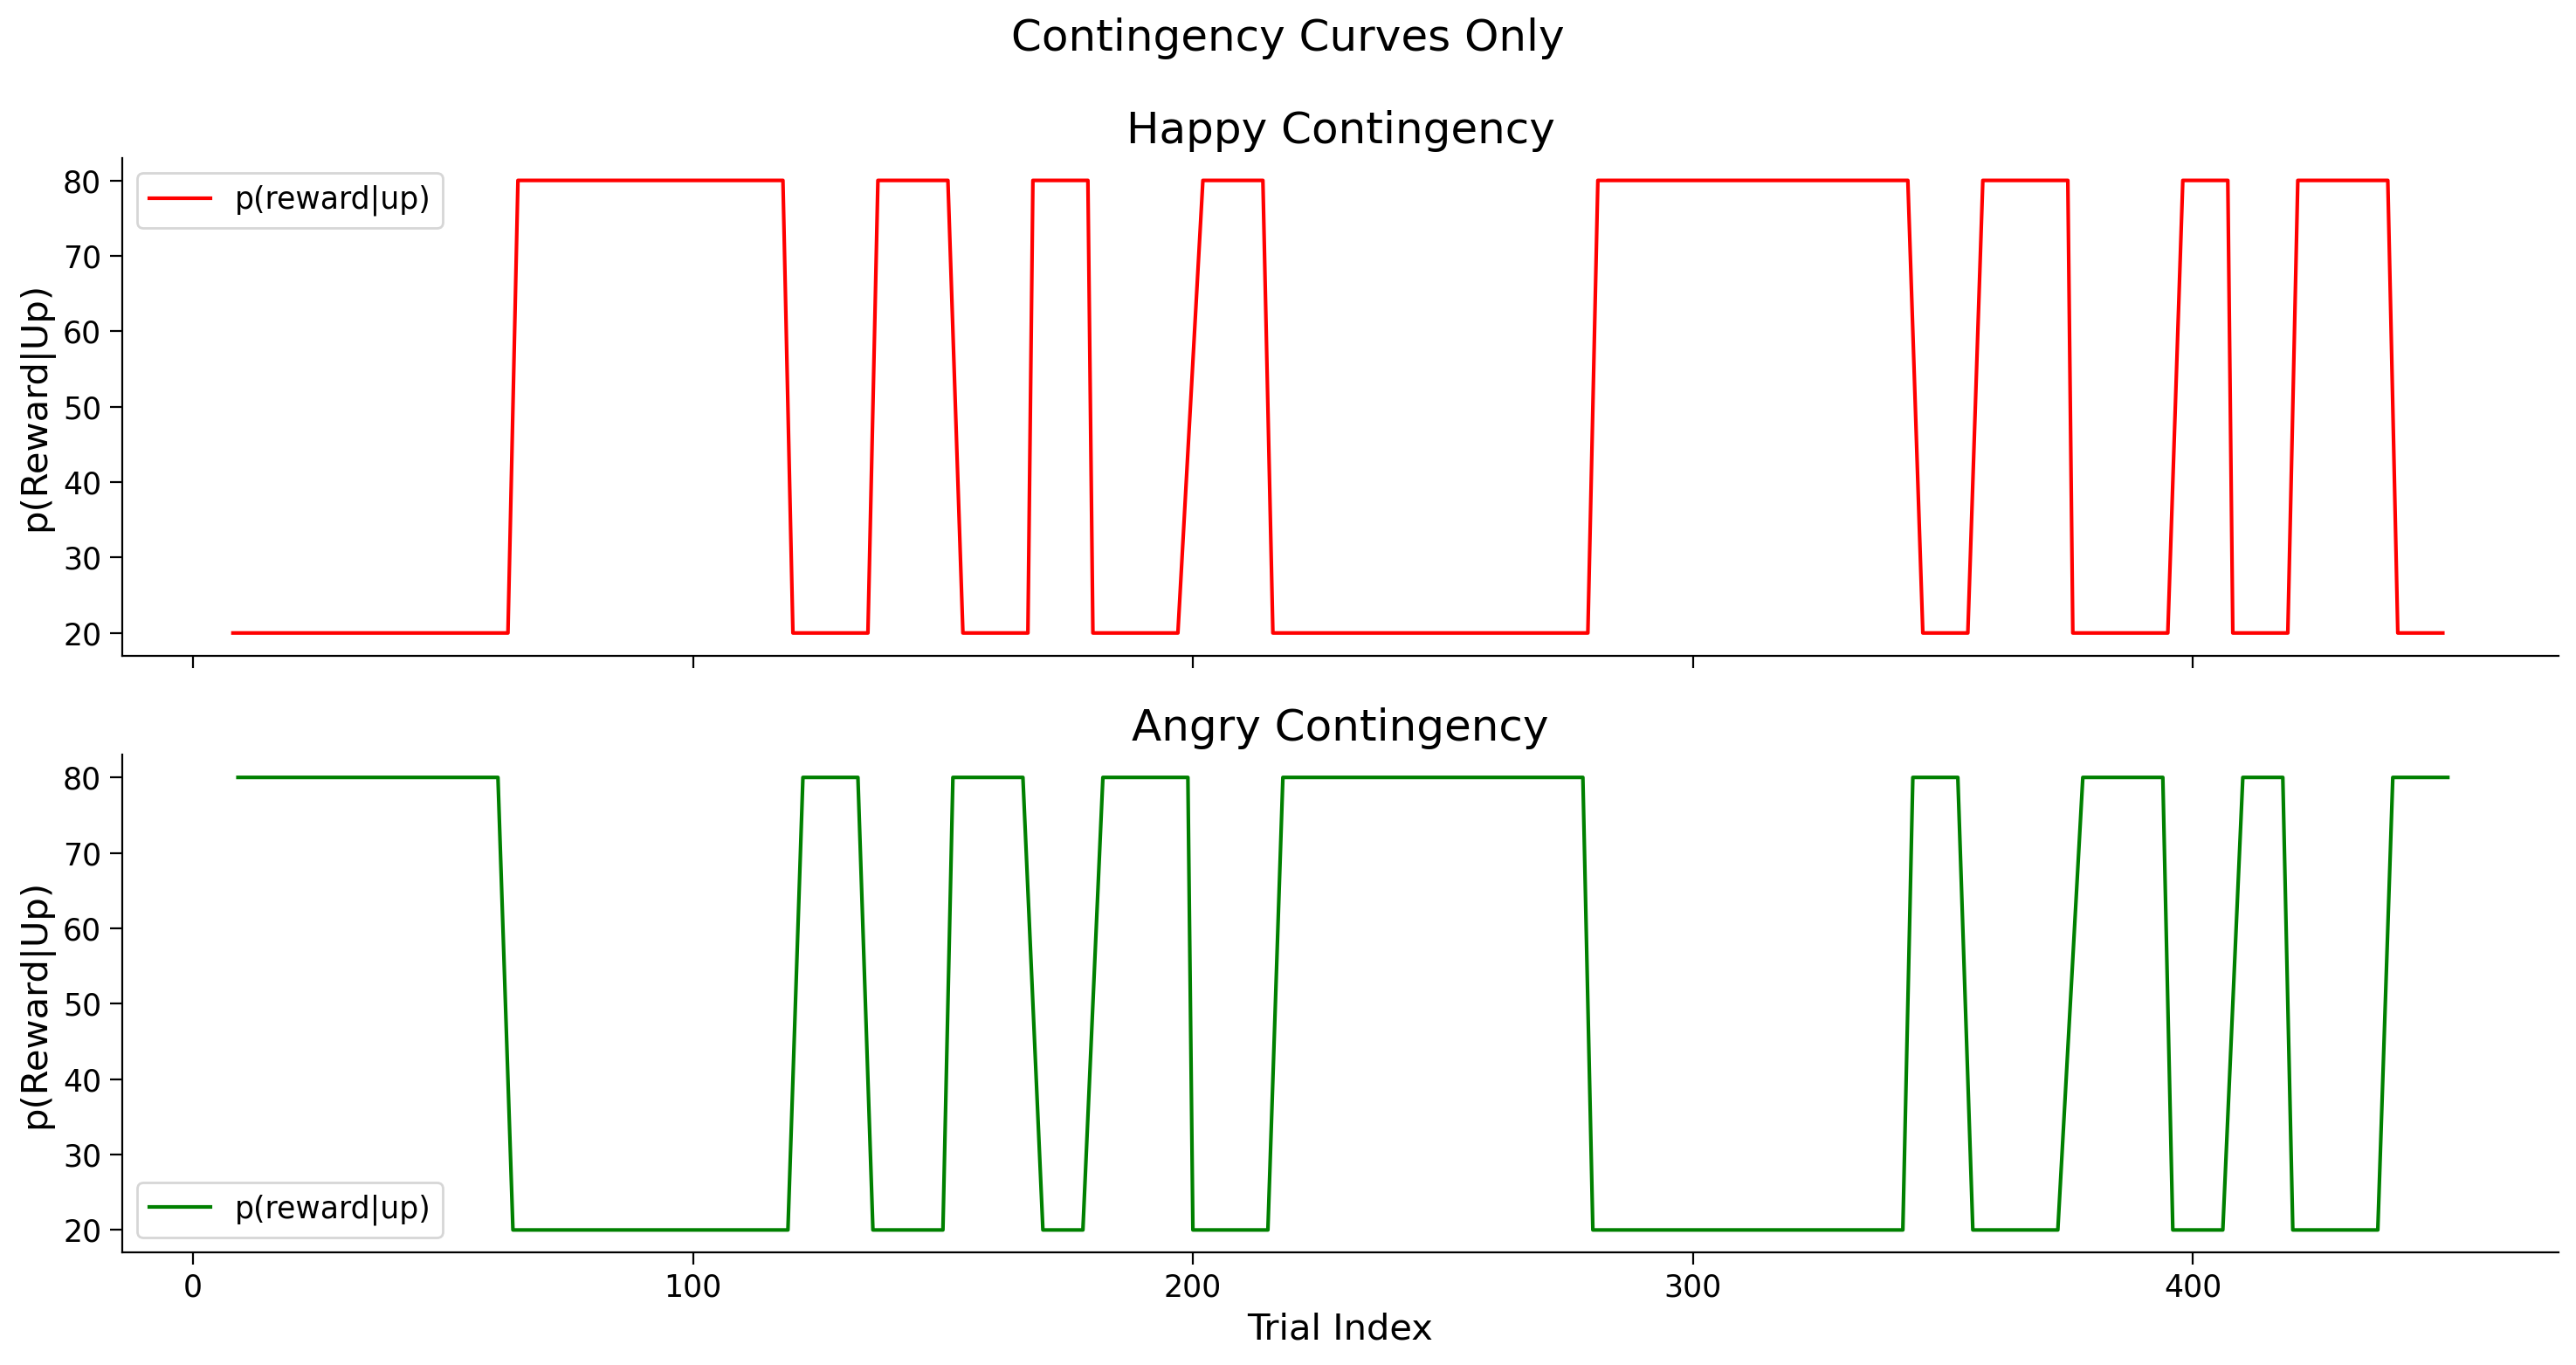

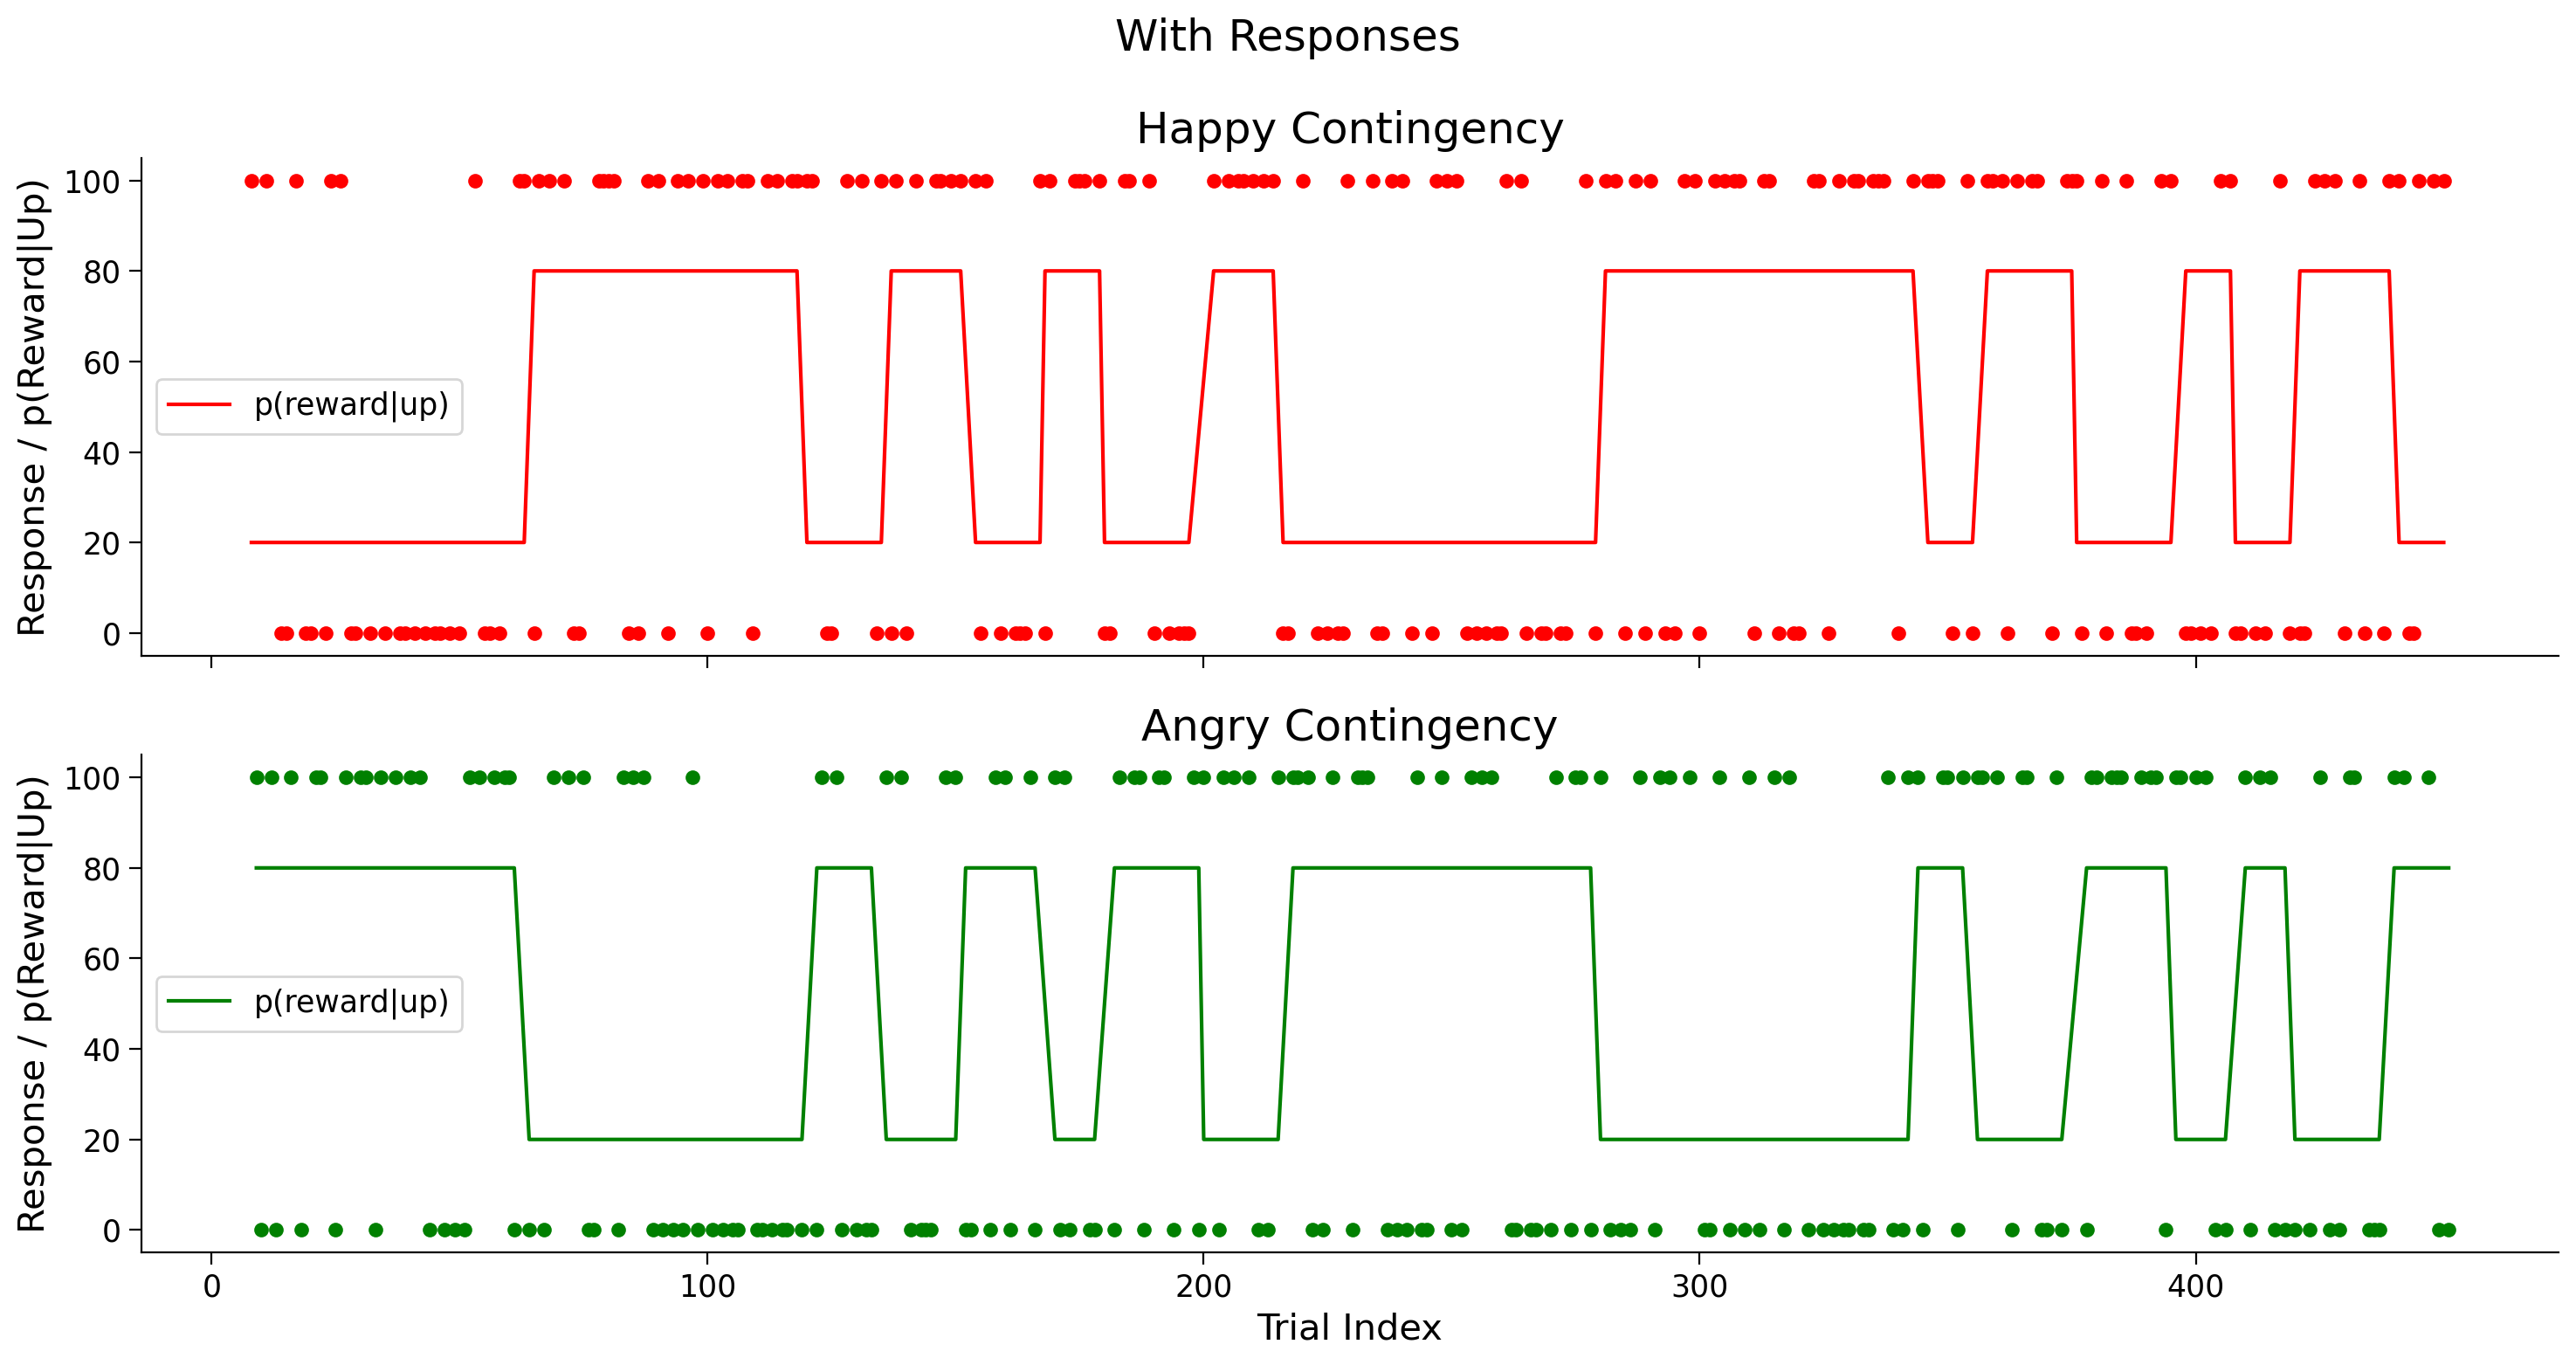

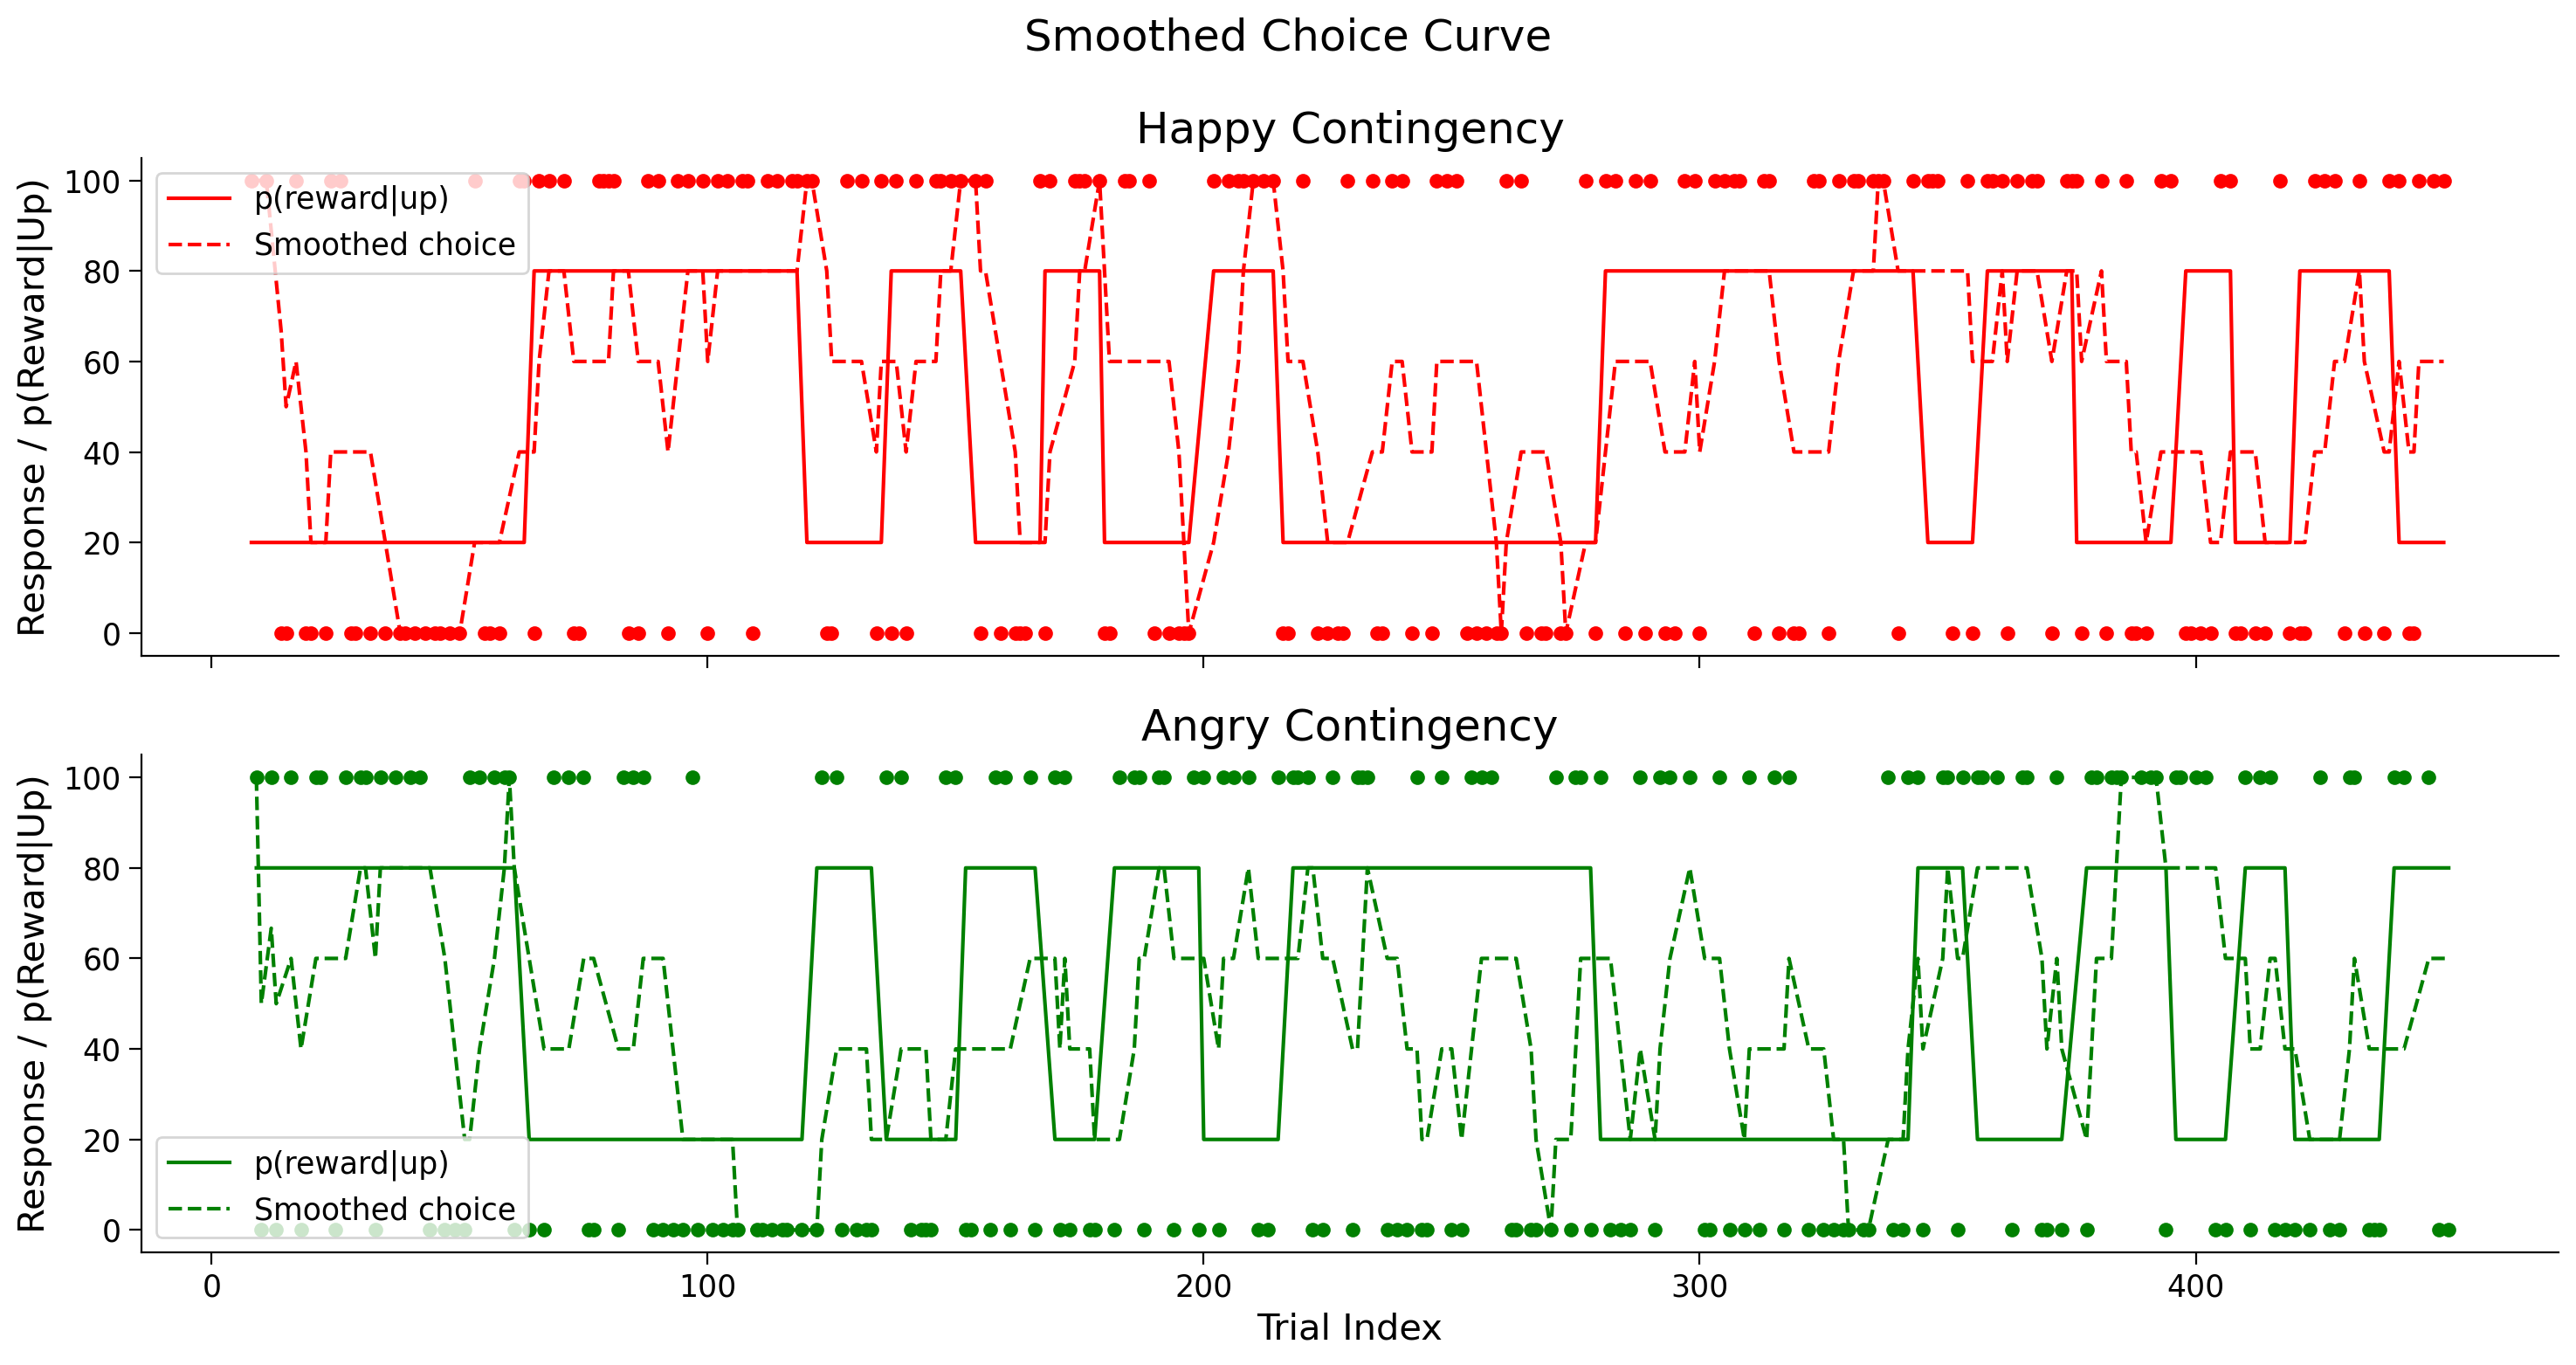

In [5]:
plot_dir = r'/project/3025011.01/derivatives/rlt/plots'
file_name = f"sub-{sub} - choice history plot.png"
sub_plot_dir = os.path.join(plot_dir, file_name)
plot_response_2outcome(results_dataframe)

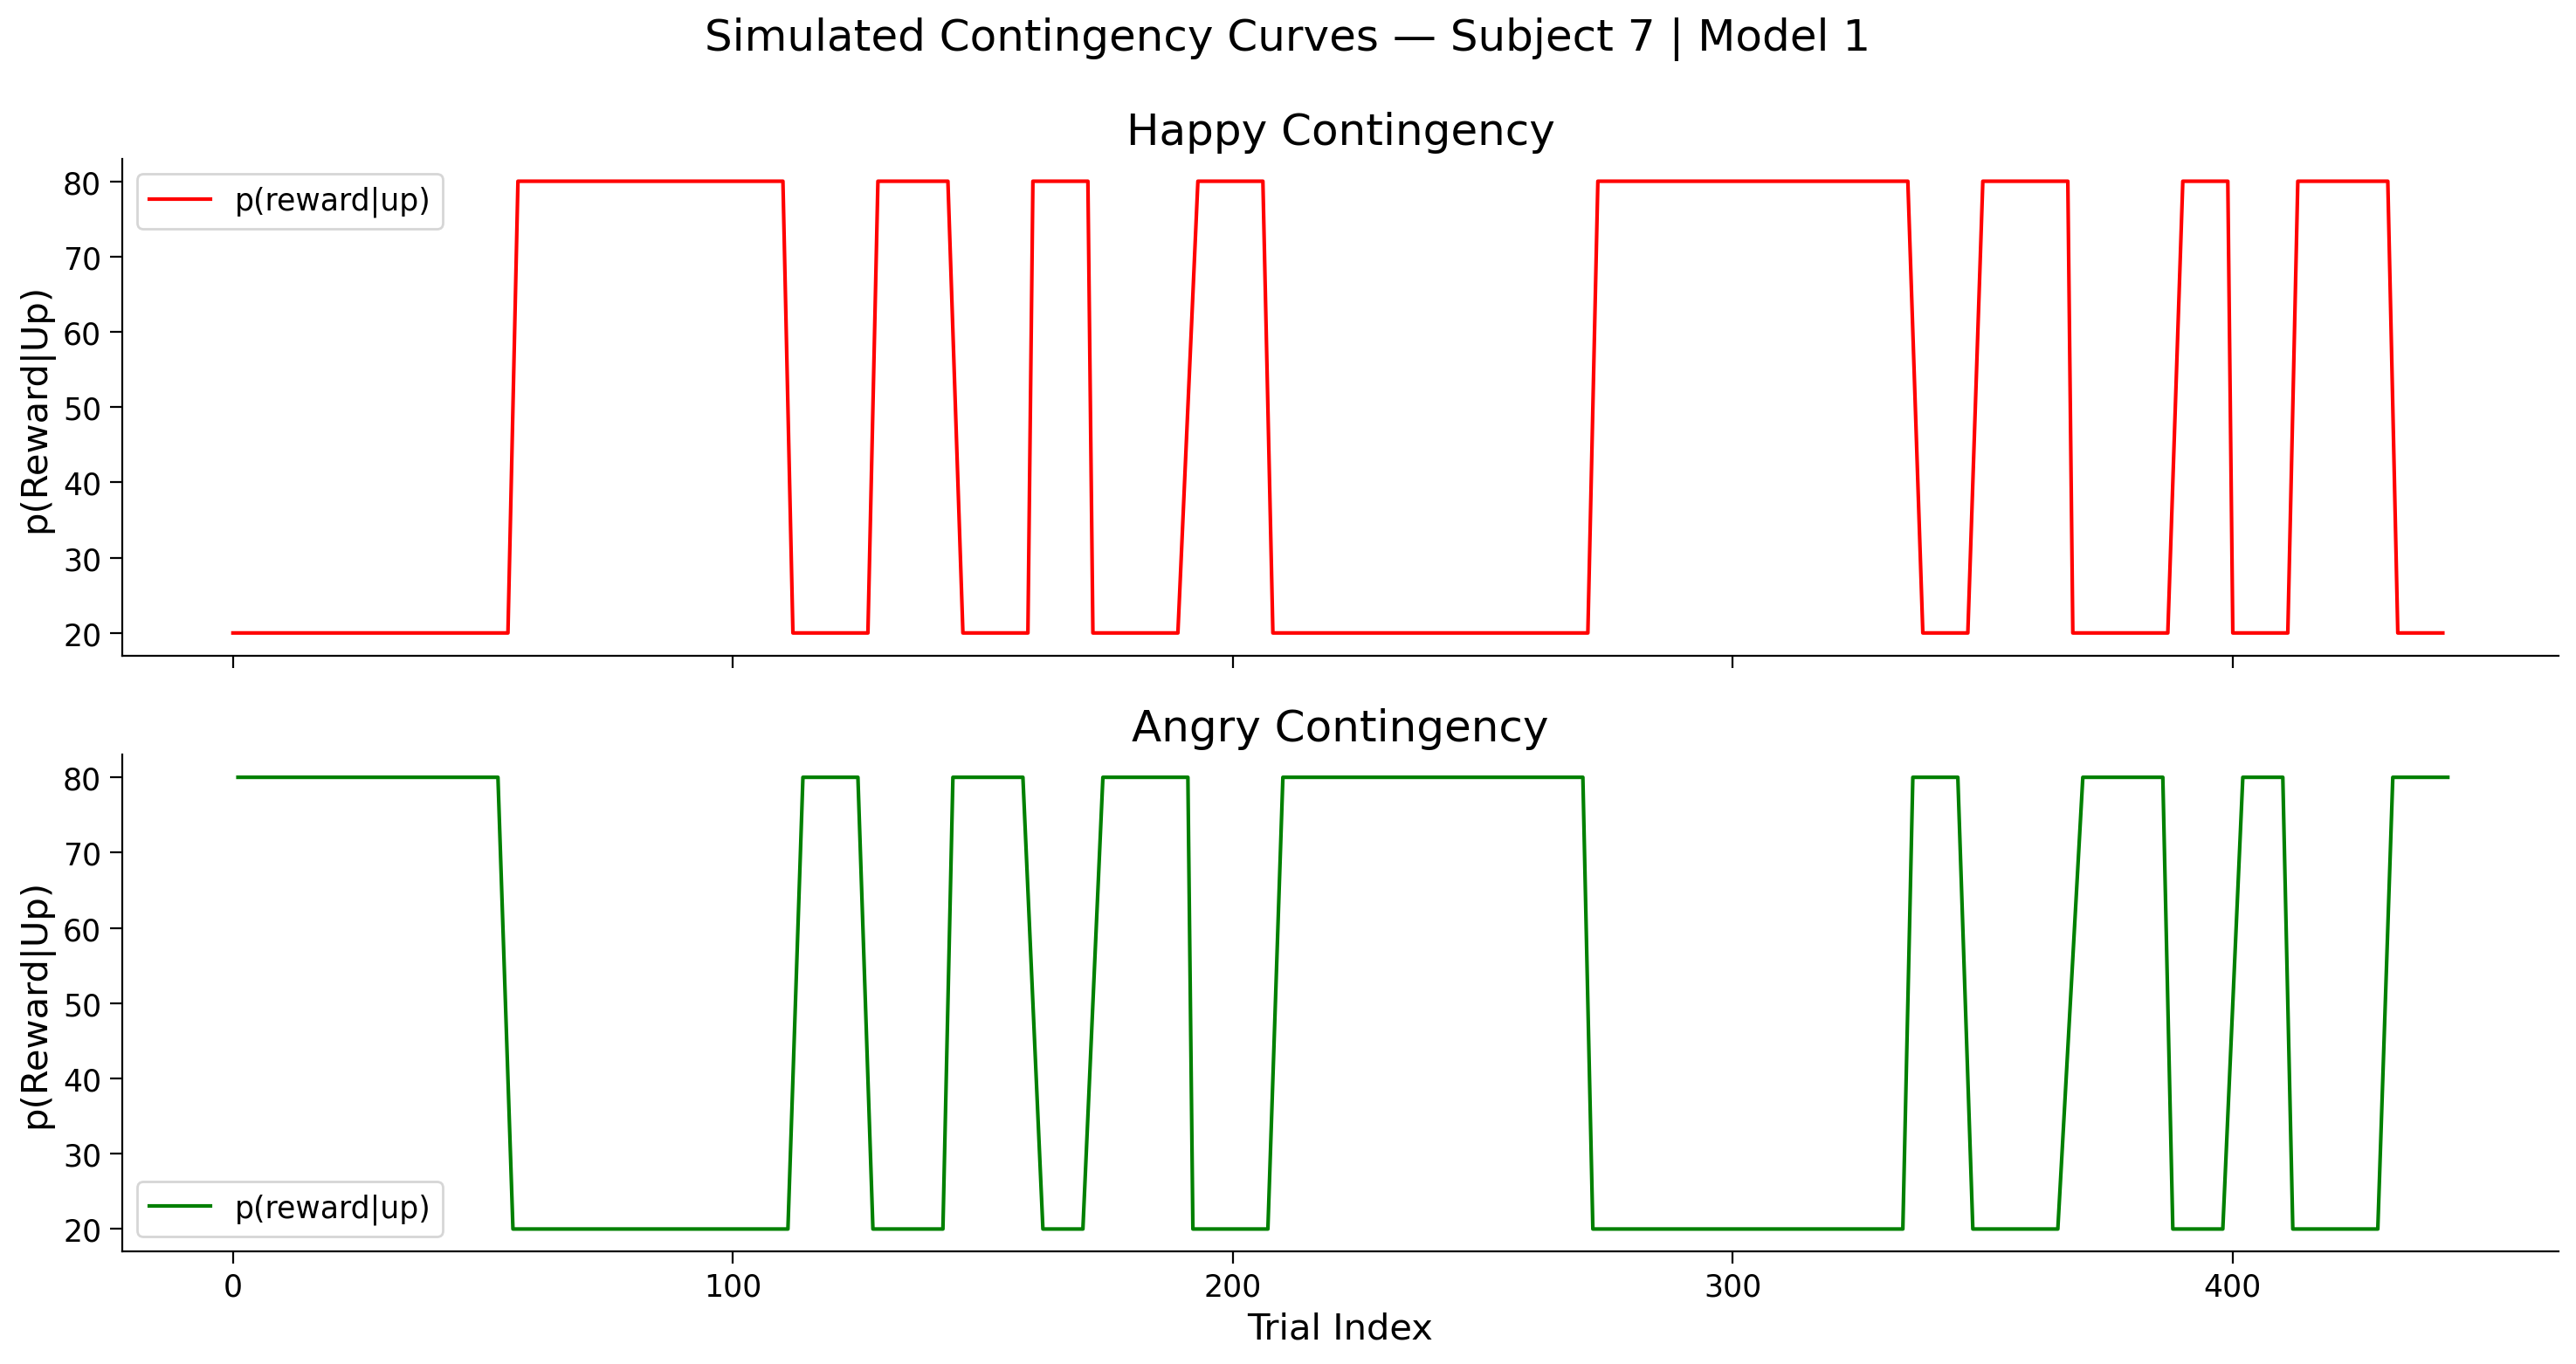

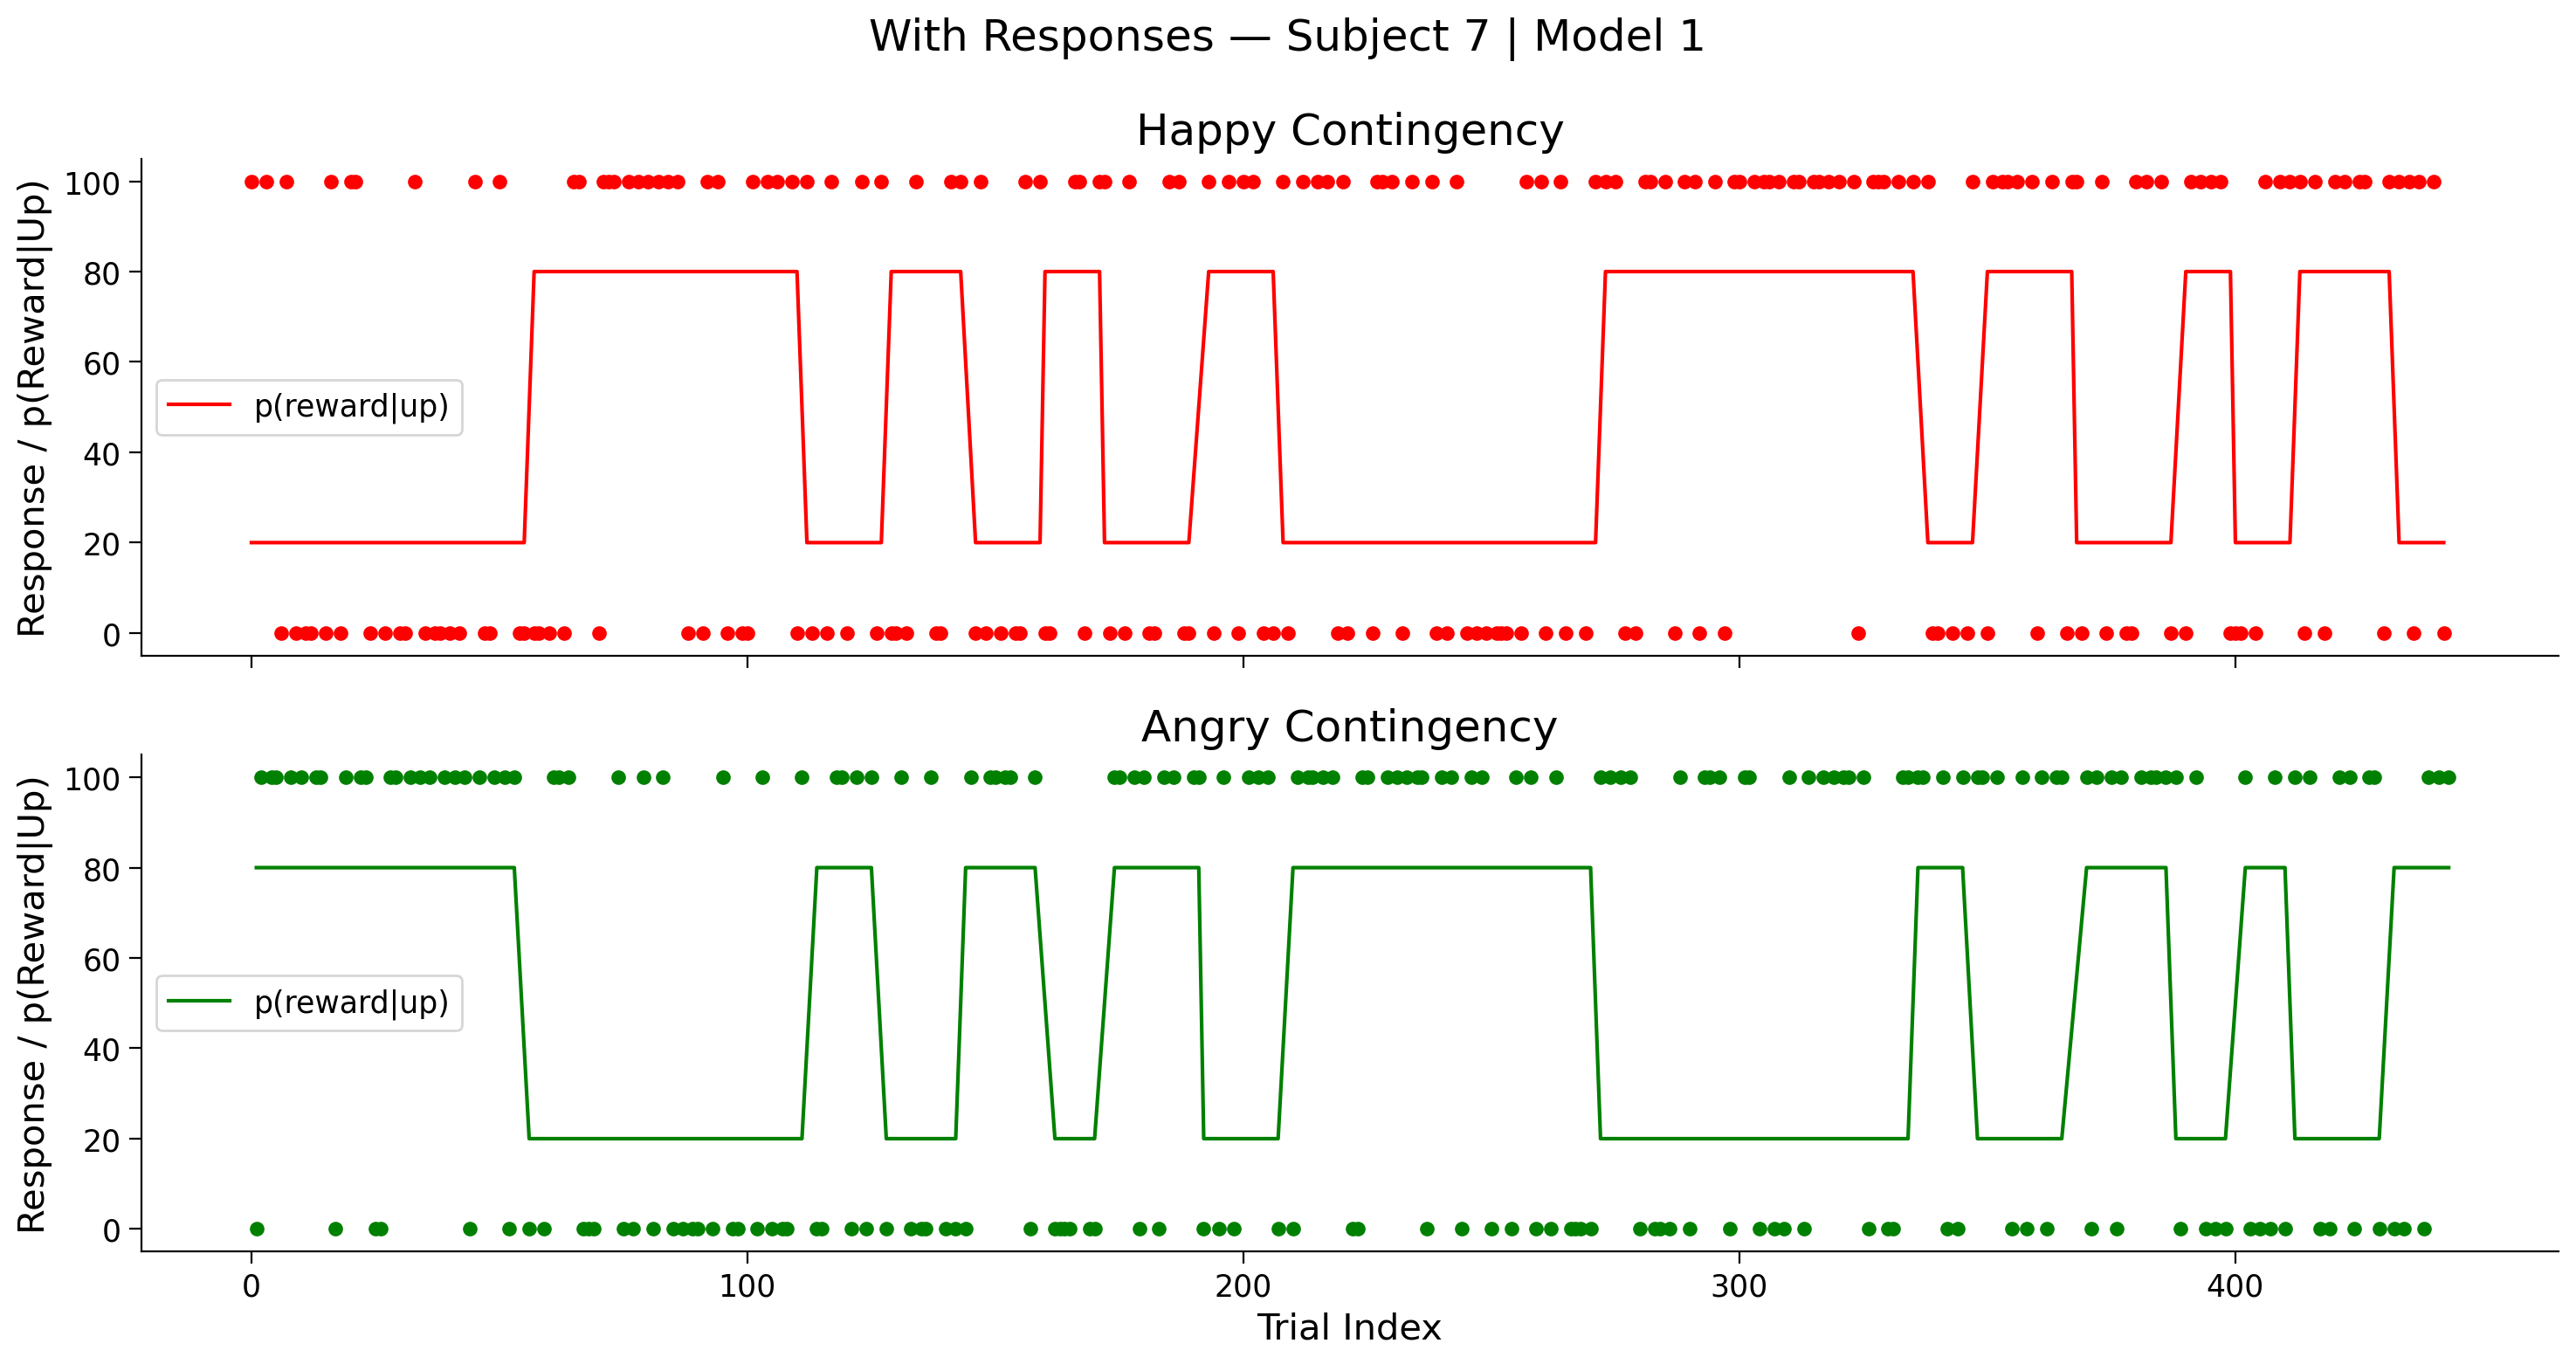

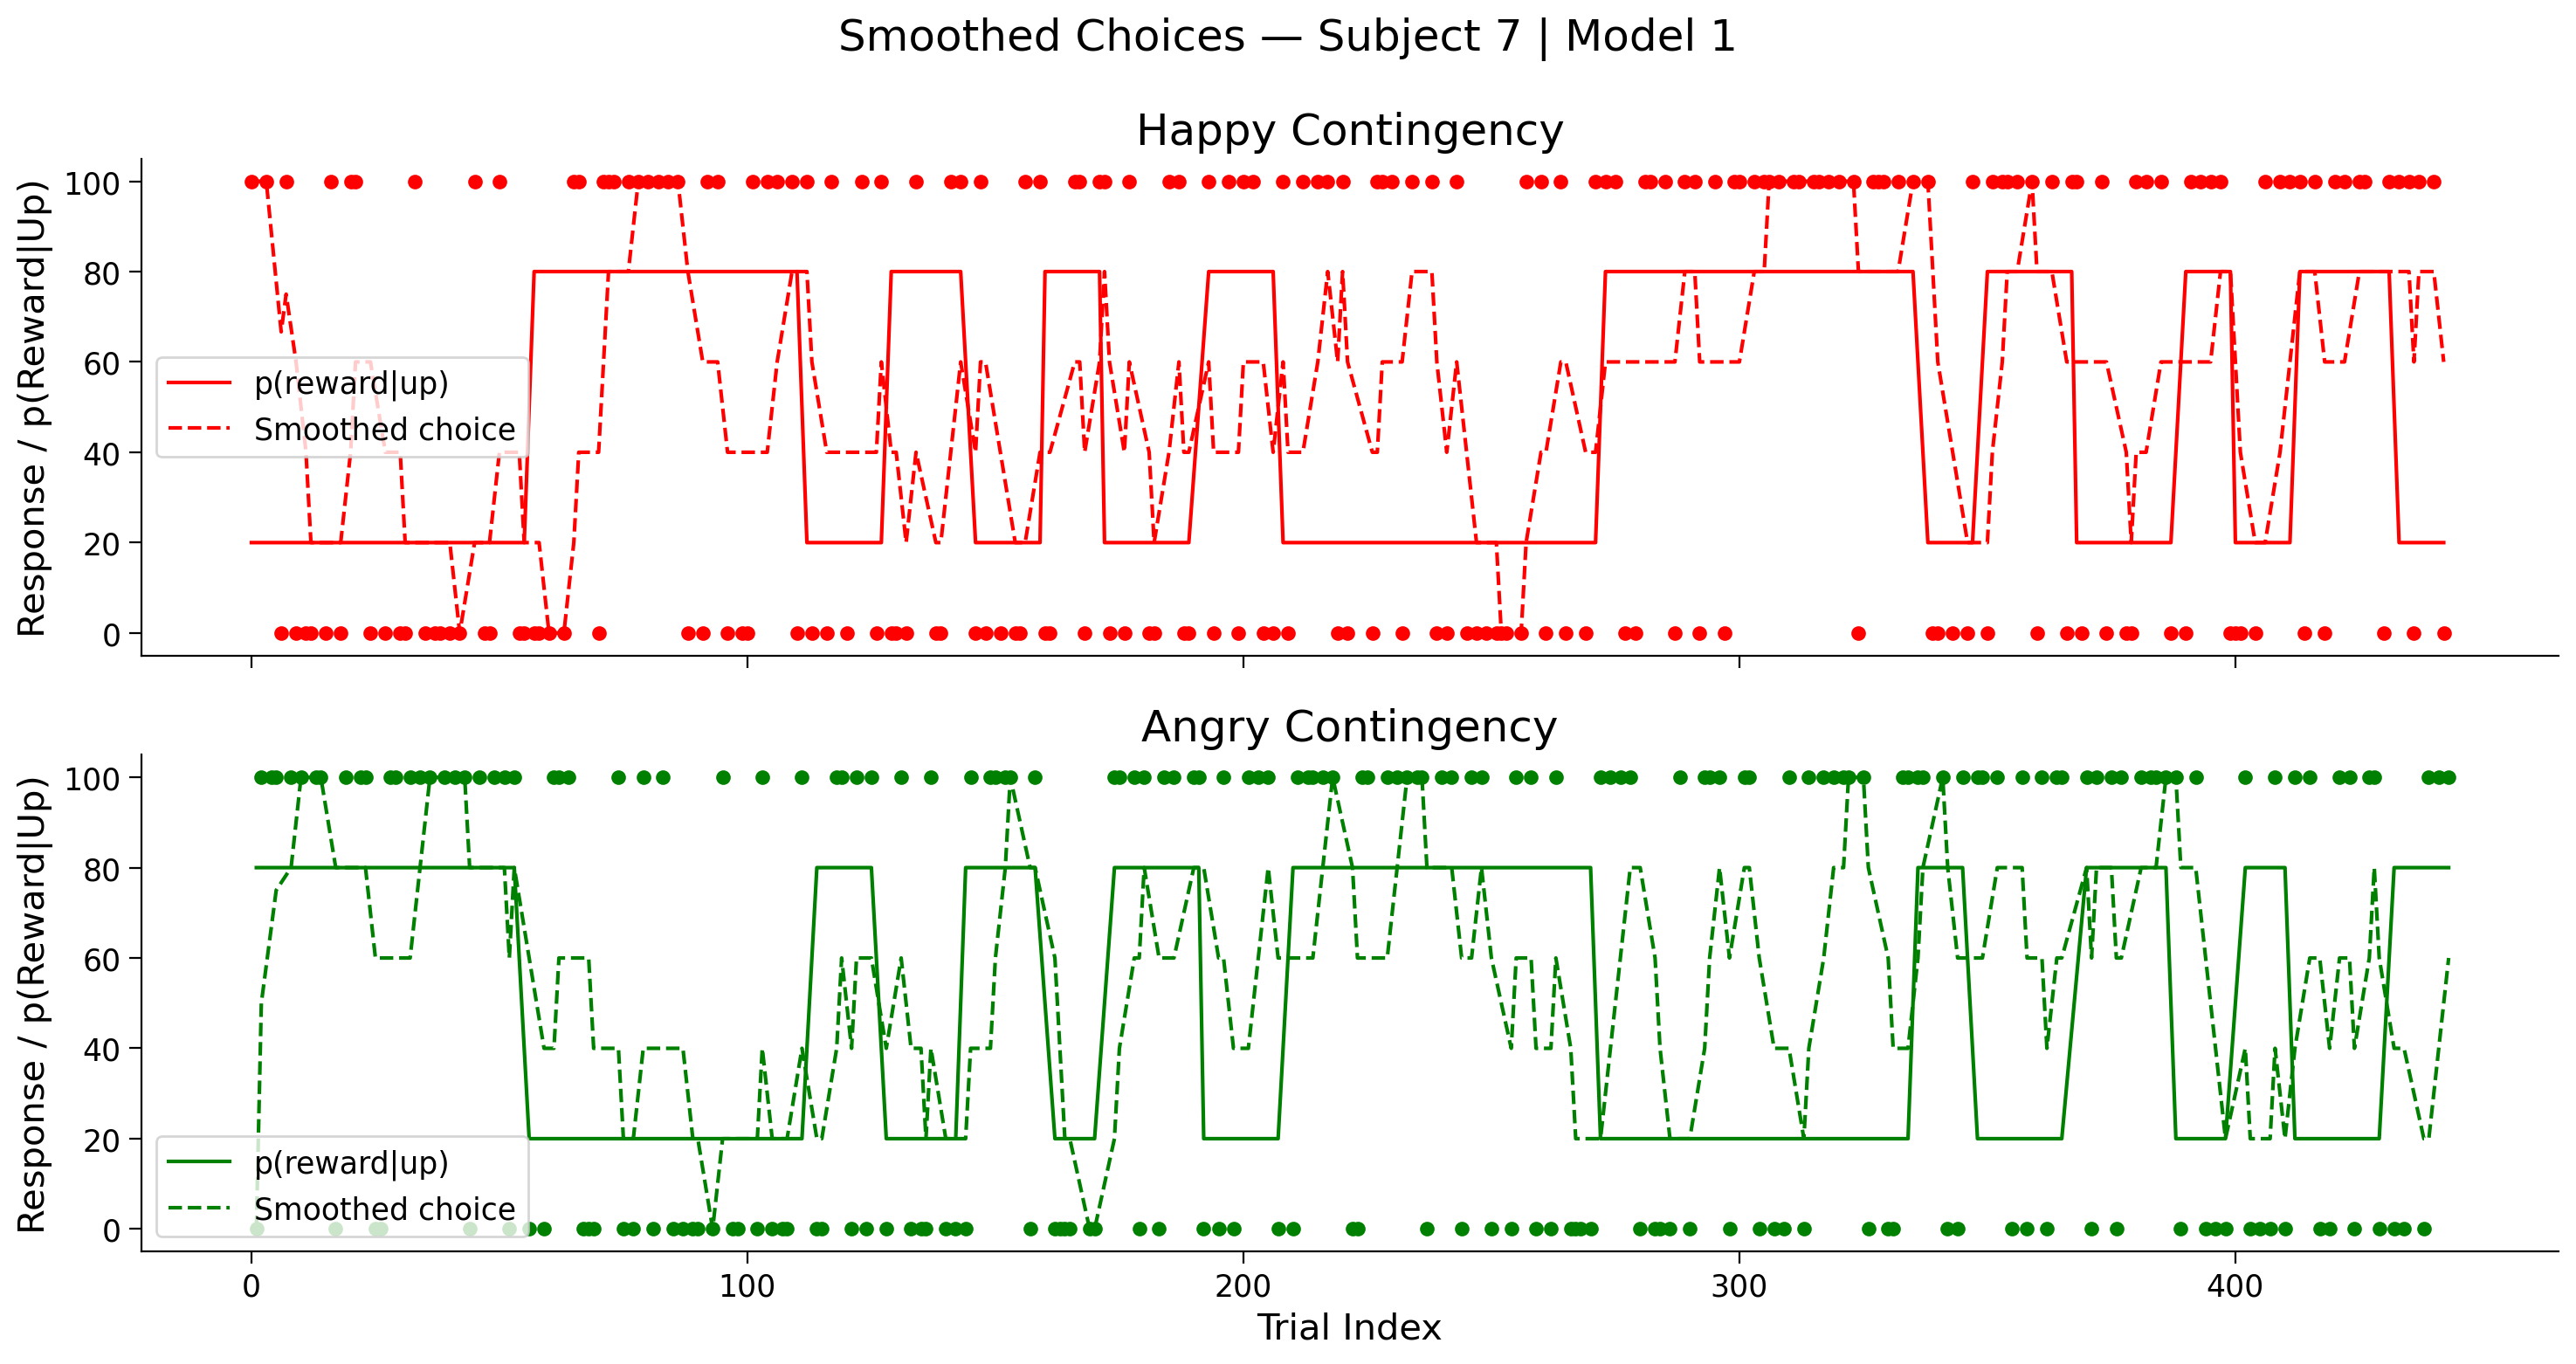

In [6]:
# let's look at some of the simulations
base_dir = r'/project/3025011.01/derivatives/rlt/analysis/' # new path for csv files
file_name = r'all_model_simulations.csv'  # replace with your actual file name
file_path = os.path.join(base_dir, file_name)
all_model_simulations = pd.read_csv(file_path, sep=",")

# let's plot subject x, model x to see how comparable it is to the real data
subject = 7
model = 1

plot_simulation_response_2outcome(all_model_simulations, subject, model)

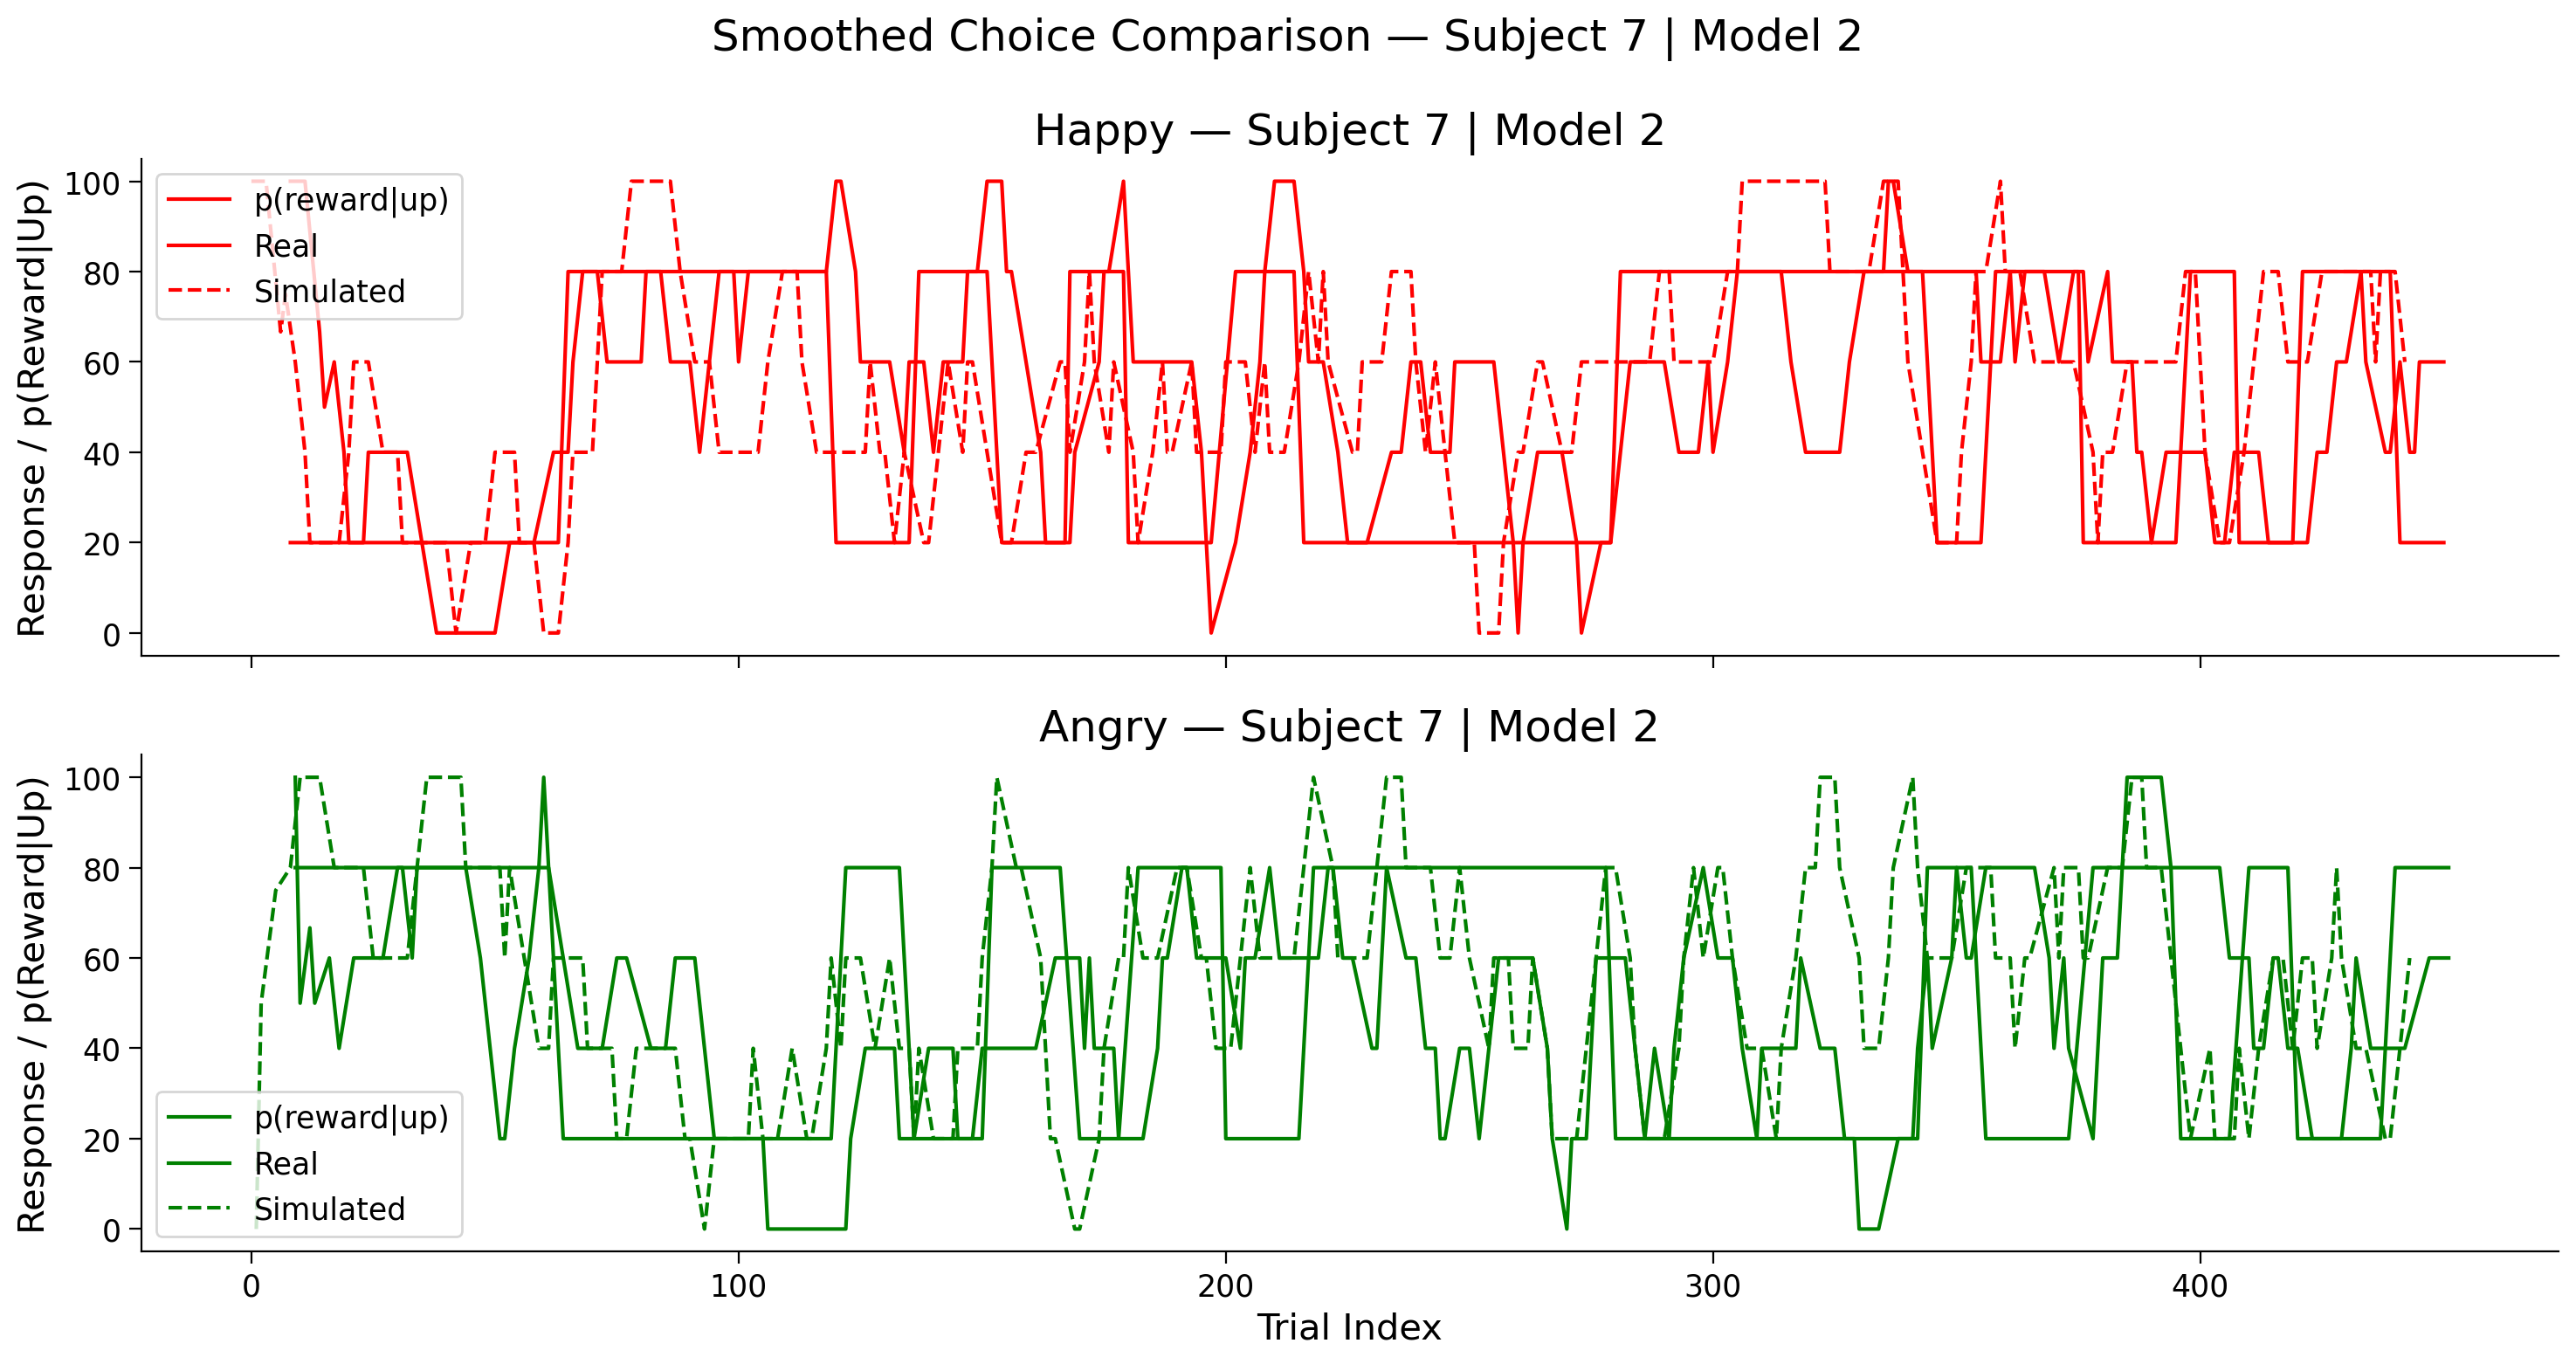

In [7]:
overlay_real_vs_simulated(df_real=results_dataframe,
                          df_simulated=all_model_simulations,
                          subject_id=7,
                          model_id=2)

### Rescola-Wagner model

In [8]:
print(results_dataframe.to_string())

     trial  emotional_cue_time response objectively_correct subjectively_correct  response_time   RT_s  feedback_time  stimuli_type       iti  probability_condition  face_type stimuli_name  reward_amount subject_id stimuli_label line_color dot_color
8        8        1.740497e+09       up               False                 True   1.740497e+09  0.563   1.740497e+09             3  2.952993                     20          8     Happy_b8            0.4     sub-07         Happy        red       red
9        9        1.740497e+09       up                True                 True   1.740497e+09  0.527   1.740497e+09             1  3.265632                     80         26    Angry_b26            0.5     sub-07         Angry      green     green
10      10        1.740497e+09     down               False                False   1.740497e+09  0.658   1.740497e+09             1  3.111530                     80         36    Angry_b36            0.4     sub-07         Angry      green     green


In [9]:
def rescorla_wagner(df, alpha=0.25):
    """ Fits a Rescorla-Wagner model to estimate value updates based on response correctness. """
    df = df.copy()
    df['value_estimate'] = 0.5  # Initial value estimate (neutral expectation)
    value_dict = {}  # Store value estimates per stimulus type
    
    for idx, row in df.iterrows():
        stim_type = row['stimuli_type']
        if stim_type not in value_dict:
            value_dict[stim_type] = 0.5  # Initialize at neutral expectation
        
        # Define reward signal
        if row['objectively_correct'] == True:
            reward = 0.1
        elif row['objectively_correct'] == False:
            reward = -0.1
        else:  # Late response
            reward = -0.1  # Penalty for missing response
        
        # Compute prediction error
        prediction_error = reward - value_dict[stim_type]
        
        # Update value estimate
        value_dict[stim_type] += alpha * prediction_error
        df.at[idx, 'value_estimate'] = value_dict[stim_type]
    
    return df

In [10]:
df_rw = rescorla_wagner(results_dataframe)
print(df_rw[['trial', 'value_estimate']].to_string())

     trial  value_estimate
8        8        0.350000
9        9        0.350000
10      10        0.237500
11      11        0.237500
12      12        0.153125
13      13        0.089844
14      14        0.153125
15      15        0.089844
16      16        0.042383
17      17        0.042383
18      18        0.006787
19      19        0.006787
20      20       -0.019910
21      21       -0.019910
22      22       -0.039932
23      23       -0.039932
24      24       -0.054949
25      25       -0.054949
26      26       -0.066212
27      27       -0.066212
28      28       -0.074659
29      29       -0.080994
30      30       -0.074659
31      31       -0.080994
32      32       -0.085746
33      33       -0.085746
34      34       -0.089309
35      35       -0.089309
37      37       -0.091982
38      38       -0.091982
39      39       -0.093986
40      40       -0.093986
41      41       -0.095490
42      42       -0.095490
43      43       -0.096617
44      44       -0.096617
4

# Let's try Piray's (2019) approach

## M1: Rescorla-Wagner

In [12]:
# Assuming df is your DataFrame
df = results_dataframe.copy()
df = df[(df['response'].isin(['down', 'up'])) & (df['objectively_correct'].isin(['True', 'False']))]
df['reward'] = df['subjectively_correct'].map({'True': 0.1, 'False': -0.1})
df['action_code'] = df['response'].map({'down': 1, 'up': 2})
df['stim_code'] = df['stimuli_label'].map({'Happy': 0, 'Angry': 1})  # 0 or 1

# ONLY FOR 4 PIRAY CUES - Cue index: (stimulus × 2) + (action - 1)
# df['cue_index'] = df['stim_code'] * 2 + (df['action_code'] - 1)

# Get number of trials
n_trials = df['trial'].nunique()
n_cues = 2 # 4 for PIRAY

# Create arrays of shape [n_trials, 4]
actions = np.zeros((n_trials, n_cues), dtype=int)
outcomes = np.zeros((n_trials, n_cues))

# Iterate safely over the filtered rows
for t, (_, row) in enumerate(df.iterrows()):
    c = int(row['stim_code'])
    actions[t, c] = int(row['action_code'])
    outcomes[t, c] = float(row['reward'])

In [13]:
# Your model_m1 function should accept params and data
data = {
    'choice': actions,
    'outcome': outcomes
}

# np.set_printoptions(precision=5, suppress=True)

def neg_log_likelihood(params):
    return -helpers.model_m1_speakup(params, data)

# Initial guess
x0 = np.array([np.log(5), 0.5, 0.05])
bounds = [(None, None), (None, None), (None, None)]

result = minimize(neg_log_likelihood, x0, bounds=bounds, method='L-BFGS-B')

In [14]:
print("Best-fitting parameters:", result.x)
print("Log-likelihood:", -result.fun)
print("LR:")
print(expit(result.x[1]))
print("Beta:")
print(np.exp(result.x[0]))

Best-fitting parameters: [ 1.80307764 -0.9201401  -0.16427099]
Log-likelihood: -279.29875390215693
LR:
0.28492934844647594
Beta:
6.068294781894461


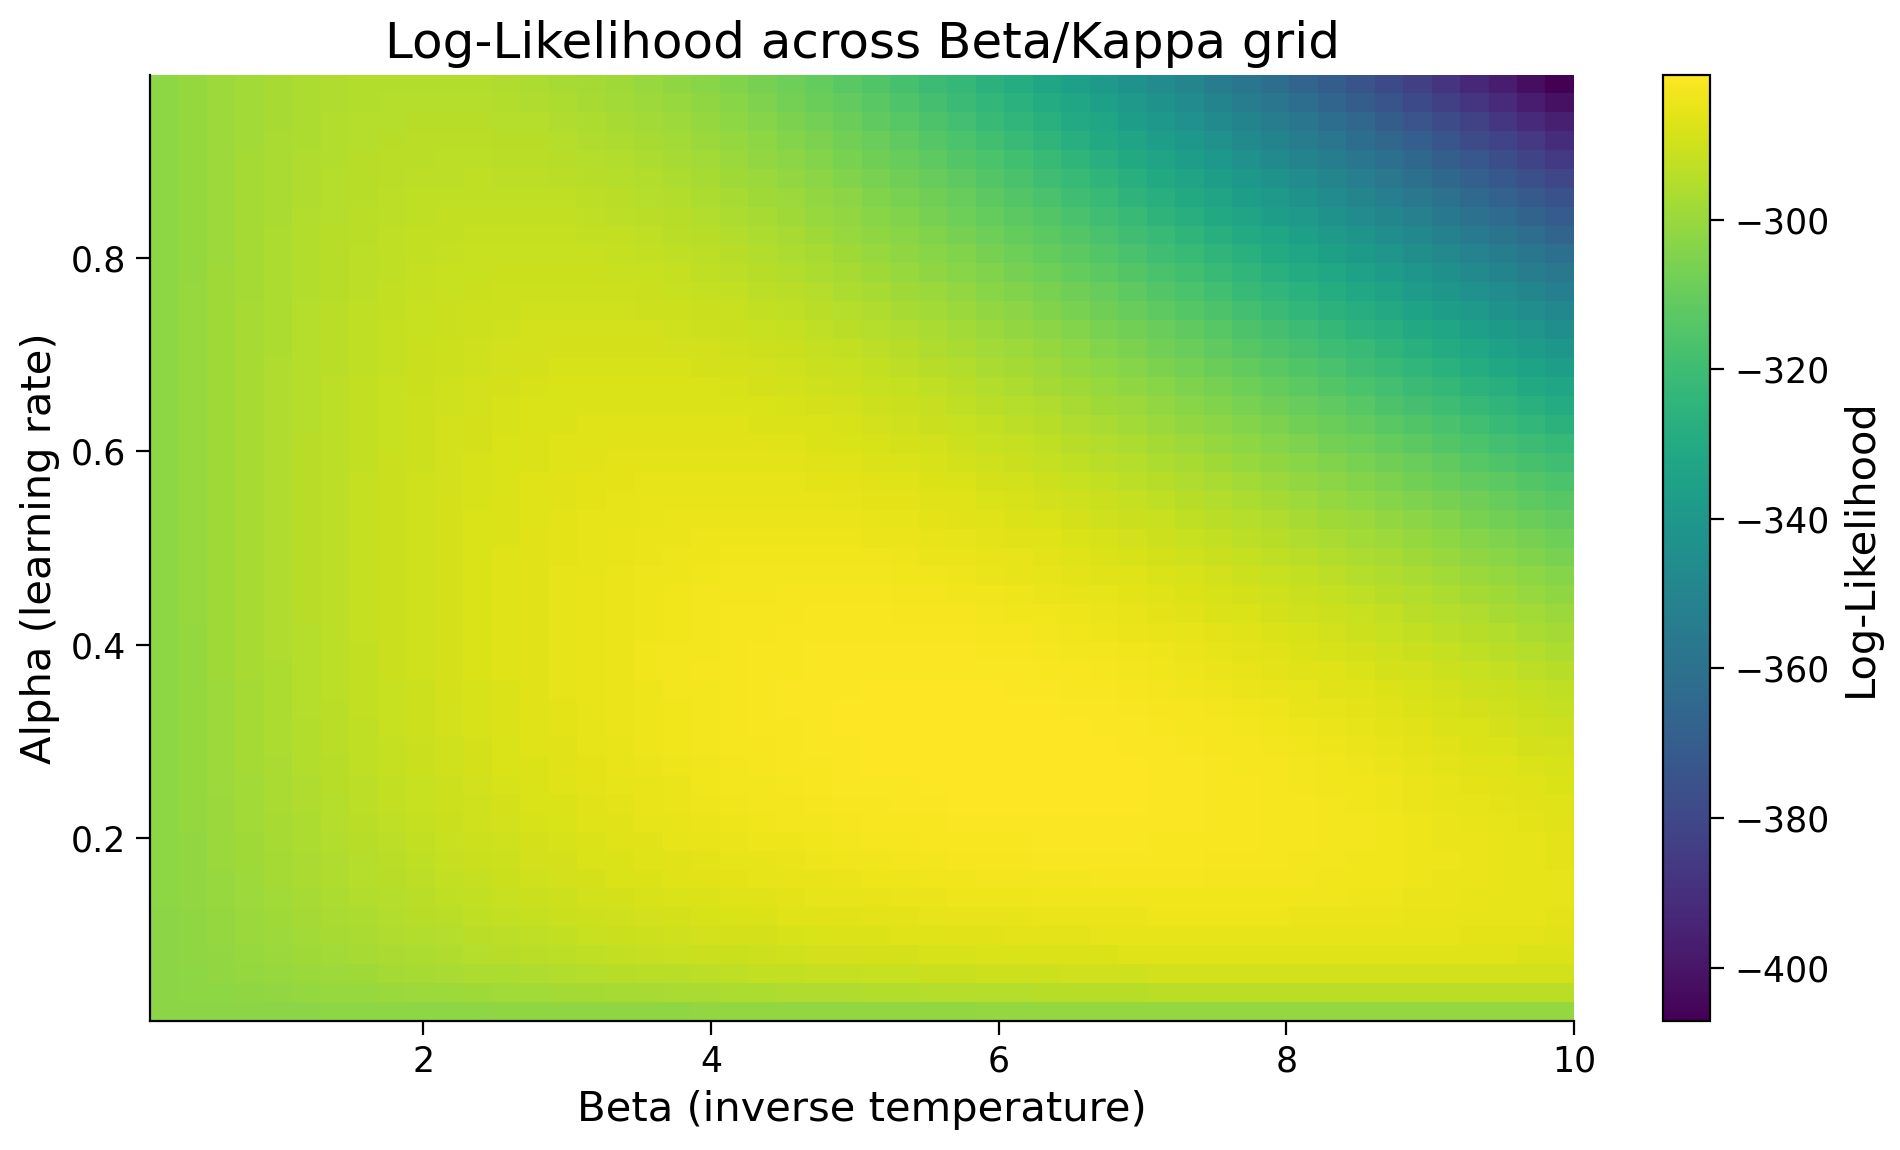

In [15]:
# Define the ranges to test (in actual scale)
beta_vals = np.linspace(0.1, 10, 50)     # inverse temperature
kappa_vals = np.linspace(0.01, 0.99, 50) # learning rate

# Dummy values for other params
be = 0 

# Prepare a matrix to store log-likelihoods
loglik_grid = np.zeros((len(kappa_vals), len(beta_vals)))

# Your data must be in this structure
# data = {'choice': ..., 'outcome': ...}
# Replace with actual data
# Ensure 'choice' and 'outcome' are numpy arrays of shape (n_trials, n_cues)

for i, kappa in enumerate(kappa_vals):
    for j, beta in enumerate(beta_vals):
        params = np.array([
            np.log(beta),         # beta (transformed)
            logit(kappa),         # kappa1 (transformed)
            be            # bias terms
        ])
        loglik = helpers.model_m1_speakup(params, data)
        loglik_grid[i, j] = loglik

# Plotting
plt.figure(figsize=(10, 6))
plt.imshow(loglik_grid, aspect='auto', origin='lower',
           extent=[beta_vals[0], beta_vals[-1], kappa_vals[0], kappa_vals[-1]])
plt.colorbar(label='Log-Likelihood')
plt.xlabel('Beta (inverse temperature)')
plt.ylabel('Alpha (learning rate)')
plt.title('Log-Likelihood across Beta/Kappa grid')
plt.show()

In [16]:
# Find the index of the maximum log-likelihood
max_idx = np.unravel_index(np.argmax(loglik_grid), loglik_grid.shape)
best_kappa = kappa_vals[max_idx[0]]
best_beta = beta_vals[max_idx[1]]
best_loglik = loglik_grid[max_idx]

print(f"Optimal beta: {best_beta:.3f}")
print(f"Optimal kappa: {best_kappa:.3f}")
print(f"Maximum log-likelihood: {best_loglik:.2f}")

Optimal beta: 5.959
Optimal kappa: 0.290
Maximum log-likelihood: -280.61


## M2: Hybrid model

Weighted sum between static and dynamic learning rate. Quantify dynamic component with associability $A_t$ (random diffusion and surprise) 

In [17]:
# Your model_m1 function should accept params and data
data = {
    'choice': actions,
    'outcome': outcomes
}

# np.set_printoptions(precision=5, suppress=True)

def negative_loglik(params):
    loglik, *_ = helpers.model_m2_speakup(params, data)
    return -loglik  # We minimize this

beta_i = np.log(5)
lambda_i = 0.5
weight_i = 0.5
kappa_i = 0
bb_i = 0.05

# Initial guess
x0 = np.array([beta_i, lambda_i, weight_i, kappa_i, bb_i])

# Parameter bounds:
# beta      : [0, 15] (after np.exp, so this is in real space)
# lambda1   : [0, 1]  (after expit)
# weight1   : [0, 1]  (after expit)
# kappa1    : [0, 1]  (after expit)
# bias be   : [0, 1]  (in real space — assuming you want a small bias range)
bounds = [
    (0, 15),   # beta
    (-6, 6),     # lambda (raw, passed through expit)
    (-6, 6),     # weight (raw, passed through expit)
    (-6, 6),     # kappa (raw, passed through expit)
    (0, 1)     # bias
]

# result = minimize(negative_loglik, x0, bounds=bounds, method='L-BFGS-B')

# print("Best-fitting parameters:", result.x)
# print("Log-likelihood:", -result.fun)
# print("LR:")
# print(expit(result.x[4]))
# print("Beta:")
# print(np.exp(result.x[0]))

In [18]:
# Number of random restarts
n_iterations = 1

best_result = None
best_nll = np.inf  # best negative log-likelihood

for i in range(n_iterations):
    # Random initialization within bounds
    init_params = np.array([
        np.random.uniform(0.1, 4),  # beta
        np.random.uniform(-6, 6),   # lambda
        np.random.uniform(-6, 6),   # weight
        np.random.uniform(-6, 6),   # kappa
        np.random.uniform(0, 1),   # bias
    ])

    result = minimize(
        negative_loglik,
        init_params,
        method='L-BFGS-B',
        bounds=bounds
    )

    if result.fun < best_nll:
        best_nll = result.fun
        best_result = result
        print(f"New best at iteration {i}: NLL = {best_nll:.4f}")

# Final result
print("\nBest parameters (raw):", best_result.x)
print("Best NLL:", best_nll)

# If you want to transform them to interpretable space:
beta_fit = np.exp(best_result.x[0])
lambda_fit = expit(best_result.x[1])
weight_fit = expit(best_result.x[2])
kappa_fit = expit(best_result.x[3])
bias_fit = best_result.x[4]

print("\nTransformed parameters:")
print(f"  beta   = {beta_fit:.4f}")
print(f"  lambda = {lambda_fit:.4f}")
print(f"  weight = {weight_fit:.4f}")
print(f"  alpha  = {kappa_fit:.4f}")
print(f"  bias   = {bias_fit:.4f}")

New best at iteration 0: NLL = 280.6137

Best parameters (raw): [ 1.78209183 -4.51591522 -2.47446784 -0.79295948  0.        ]
Best NLL: 280.6137462825103

Transformed parameters:
  beta   = 5.9423
  lambda = 0.0108
  weight = 0.0777
  alpha  = 0.3115
  bias   = 0.0000


## Testing methods section

In [19]:
from scipy.special import expit

def model_hybrid(lambda_, weight, kappa, actions, outcome):
    """
    Hybrid Rescorla-Wagner / Kalman model update.
    
    Args:
        lambda_ : list or array of length nq
        weight  : list or array of length nq
        kappa   : list or array of length nq
        actions : (nt, nq) array of actions (1 or 2) per trial and cue
        outcome : (nt, nq) array of outcomes per trial and cue
        
    Returns:
        xQ      : (nt+1, nq) predicted Q differences (go - no-go)
        xalpha  : (nt, nq) effective learning rates
        xdelta  : (nt, nq) prediction errors
    """
    # ensure that both actions and outcome (reward/punishment) are arrays, for math
    outcome = np.array(outcome)
    actions = np.array(actions)
    
    # we take the dimensions of the number of trials (rows) x number of stimulus-action combinations (all might have different probs)
    nt, nq = outcome.shape

    # just check that ncue is a multiple of 2; usually 2, but we might have a multiple
    ncue = 2
    if nq % ncue != 0:
        raise ValueError("Unexpected number of cues (should be multiple of 2)")
    
    # if it's a multiple of 2, we should incorporate that (different cue sets?)
    nrep = nq // ncue
    lambda_ = np.tile(lambda_, nrep)
    weight = np.tile(weight, nrep) # weights for K_t, if = 0 only static, if = 0 only dynamic
    kappa = np.tile(kappa, nrep) # the static learning rate


    xalpha = np.full((nt, nq), np.nan) # will be used to store kalman; will be 1 if only static learning used 
    xdelta = np.full((nt, nq), np.nan) # will be used to store prediction errors
    xQ = np.full((nt + 1, nq), np.nan) # will be used to store Q-value differences (i.e., expected value of action 1 - action 2)
    xQ[0, :] = 0.0 # that difference will be 0 before the first trial

    q = np.zeros((nq, 2))  # for each cue: Q-values for actions 1 and 2
    Apost = lambda_ * (1 - lambda_) * 2 # initial posterior uncertainty per cue; only relevant for adaptive learning

    for t in range(nt): # let's go over all trials
        a = actions[t, :]  # action indices on this trial
        o = outcome[t, :]  # observed outcomes on this trial
        
        active = a > 0 # let's get the index of the relevant actions-stimulus combination
        active_index = (np.where(active)[0], a[active] - 1)  # convert to 0-based indexing; a values are 1 or 2 -> we want 0 or 1 instead
        
        # computing the Kalman gain for the hybrid model
        A = lambda_ * Apost
        kalman = weight * A + (1 - weight)

        # updating prediction errors (delta) and q-values
        delta = np.zeros(nq) # delta = o - q[idx]
        delta[active] = o[active] - q[active_index] # generating prediction errors only for the relevant stimulus-action combination
        q[active_index] += kappa[active] * kalman[active] * delta[active] # both indices for kappa are the same in this model (no different learning rates for different stimuli), but we still use an array for other models

        # updating the posterior uncertainty, which gets larger if the PE was large
        Apost = A + (1 - lambda_) * (delta ** 2)

        # updating all values
        qq1 = q[:, 0]
        qq2 = q[:, 1]
        xQ[t + 1, :] = qq1 - qq2 # subtracting the expected values for action 1 from action 2
        xdelta[t, :] = delta
        xalpha[t, :] = kalman

    return xQ, xalpha, xdelta

In [20]:
lambda1 = [0, 0] # [0, 0, 0, 0]
weights = [0, 0] # [0, 0, 0, 0]
kappa1 = [expit(0), expit(0)] # sigmoid of 0 -> learning rate of 0.5; -6 close to 0 and 6 close to 1
actions = np.array([
    [2, 0],
    [0, 1],
    [1, 0],
    [0, 1],
    [0, 1],
    [2, 0]
])
outcomes = np.array([
    [-1, 0],
    [0, 1],
    [-1, 0],
    [0, 1],
    [0, 1],
    [1, 0]
])
data = {
    'choice': actions,
    'outcome': outcomes
}

In [3]:
BASE_DIR = r'/project/3025011.01/data/'
sub = "11"

def load_subject_data(sub_id):
    sub_dir = f"sub-{sub_id}"
    experiment_output_path = os.path.join(BASE_DIR, sub_dir)
    recent_results = analysis_functions.list_files_with_subject_id(
        experiment_output_path, range(1, 100)
    )
    df = analysis_functions.combine_result_files(recent_results)
    df = df[~((df.index % 452 < 8)) & (df['objectively_correct'] != "Late")].copy()
    df = df[(df['response'].isin(['down', 'up'])) & df['objectively_correct'].isin(['True', 'False'])].copy()
    df['reward'] = df['subjectively_correct'].map({
        True: 1, 'True': 1,
        False: -1, 'False': -1
    })
    df['action_code'] = df['response'].map({'down': 1, 'up': 2})
    df['stim_code'] = df['stimuli_type'].map({3: 0, 1: 1}) # happy = 0, angry = 1
    df = analysis_functions.check_volatility(df)
    # print(f"Loaded data for subject {sub_id} with {len(df)} trials.")
    return df

def format_data(df):
    n_trials = df['trial'].nunique()
    n_cues = 2
    actions = np.zeros((n_trials, n_cues), dtype=int)
    outcomes = np.zeros((n_trials, n_cues))
    volatilities = np.empty(n_trials, dtype=object)
    for t, (_, row) in enumerate(df.iterrows()):
        c = int(row['stim_code'])
        actions[t, c] = int(row['action_code'])
        outcomes[t, c] = float(row['reward'])
        volatilities[t] = str(row['volatility'])
    return {'choice': actions, 'outcome': outcomes, 'volatility': volatilities}

def model_m1_speakup(params, data):
    """
    Python version of model_m1 (Rescorla-Wagner with 5 parameters).
    
    Args:
        params: numpy array of shape (5,)
        data: dict with keys 'choice' and 'outcome' (both arrays)
        
    Returns:
        loglik: float, log-likelihood of data under the model
    """
    choice = data['choice']
    outcome = data['outcome']

    def safe_expit(x):
        return expit(np.clip(x, -10, 10))  # avoids exact 0 or 1

    beta = np.exp(np.clip(params[0], -5, 4.6))  # softmax temperature, clipped to avoid extreme values
    
    kappa1 = safe_expit(params[1]) # decay rate, sigmoid to [0,1]

    # Bias terms
    be = params[2]
    
    # Construct 2-element bias vector instead of 4-element bias vector (bb)
    # we are not cueing reward/punishment separately. I.e., there is no color indicating reward or punishment. Thus, we only need a single bias value
    bb = np.array([be, -be])
    
    # Learning setup
    lambda1 = 0
    lambda2 = 0
    weight1 = 0
    weight2 = 0

    lambda_ = [lambda1, lambda2]
    weight = [weight1, weight2]
    kappa = [kappa1, kappa1]
    
    # Get model predictions
    xQ, xalpha, xdelta = model_hybrid_speakup_new(lambda_, weight, kappa, choice, outcome)
    
    # Compute log-likelihood
    X = xQ[:len(choice), :]
    Y = (choice == 1)
    
    loglik, _ = response_speakup(X, choice, beta, bb)
    return loglik

def model_m2_speakup(params, data):
    choice = data['choice']
    outcome = data['outcome']

    def safe_expit(x):
        return expit(np.clip(x, -10, 10))  # avoids exact 0 or 1
    
    beta = np.exp(np.clip(params[0], -5, 4.6))                     # softmax temperature
    lambda1 = safe_expit(params[1]) # learning rate, sigmoid to [0,1]
    weight1 = safe_expit(params[2]) # PE weighting, sigmoid to [0,1]
    kappa1 = safe_expit(params[3]) # decay rate, sigmoid to [0,1]
    
    if np.any(np.isnan([lambda1, weight1, kappa1])):
        return -np.inf, None, None, None

    # shared across cues
    weight2 = weight1
    lambda2 = lambda1
    kappa2 = kappa1

    # bias parameters
    be = params[4]

    # Construct 2-element bias vector instead of 4-element bias vector (bb)
    # we are not cueing reward/punishment separately. I.e., there is no color indicating reward or punishment. Thus, we only need a single bias value
    bb = np.array([be, -be])

    # duplicate params for each cue
    lambda_all = [lambda1, lambda2]
    weight_all = [weight1, weight2]
    kappa_all  = [kappa1, kappa2]

    # run hybrid model (this function must be implemented)
    xQ, xalf, xdelta = model_hybrid_speakup_new(lambda_all, weight_all, kappa_all, choice, outcome)

    nt = len(choice)
    X = xQ[:nt, :]  # predicted values for each trial
    Y = (choice == 1).astype(int)  # convert to binary

    loglik, CV = response_speakup(X, choice, beta, bb)

    return loglik, xalf, xdelta, CV

def model_m3_speakup(params, data):
    choice = data['choice']
    outcome = data['outcome']

    def safe_expit(x):
        return expit(np.clip(x, -10, 10))  # avoids exact 0 or 1

    beta = np.exp(np.clip(params[0], -5, 4.6))  # softmax temperature
    lambda1 = safe_expit(params[1])            # learning rate
    weight1 = safe_expit(params[2])            # weight for cue 1
    weight2 = safe_expit(params[3])            # weight for cue 2
    kappa1 = safe_expit(params[4])             # decay rate
    be = params[5]                             # bias

    if np.any(np.isnan([lambda1, weight1, weight2, kappa1])):
        return -np.inf, None, None, None

    # assume same learning rate and kappa for both cues
    lambda_all = [lambda1, lambda1]
    weight_all = [weight1, weight2]
    kappa_all  = [kappa1, kappa1]

    # Bias vector
    bb = np.array([be, -be])

    # Run hybrid model
    xQ, xalf, xdelta = model_hybrid_speakup_new(lambda_all, weight_all, kappa_all, choice, outcome)

    nt = len(choice)
    X = xQ[:nt, :]
    Y = (choice == 1).astype(int)

    loglik, CV = response_speakup(X, choice, beta, bb)

    return loglik, xalf, xdelta, CV

def response_speakup(X, choice, beta, bb):
    """
    Logistic response function with bias.
    """
    # nq = X.shape[1]
    # ncue = 2
    # if nq % ncue != 0:
    #     raise ValueError("Unexpected number of Q-values per trial")
    
    # nrep = nq // ncue
    # bias_vector = np.tile(bb, nrep)
    
    # z = X * beta + bias_vector # or '@' instead of '*' ?
    # f = 1 / (1 + np.exp(-z))
    # #print("f = " + str(f[:10]))
    # p = f * Y + (1 - f) * (1 - Y)
    # print("p = " + str(p))
    # cue_idx = np.argmax((Y == 1) | (Y == 0), axis=1)
    # p_active = p[np.arange(len(p)), cue_idx]
    # print("p_active = " + str(p_active))
    # CV = z * Y + (-z) * (1 - Y)
    # loglik = np.sum(np.log(p + 1e-10))  # add epsilon to avoid log(0)
    # return loglik, CV
    """
    Compute log-likelihood of observed choices using logistic function.

    Args:
        X: Q-value differences, shape (n_trials, n_cues)
        choice: choice array, shape (n_trials, n_cues), values in {0, 1, 2}
        beta: inverse temperature (scalar)
        bb: bias vector, shape (2,) — biases for the two cue types

    Returns:
        loglik: scalar log-likelihood
        CV: choice values (optional)
    """
    n_trials, n_cues = X.shape
    nrep = n_cues // 2
    bias_vector = np.tile(bb, nrep)

    z = X * beta + bias_vector
    f = 1 / (1 + np.exp(-z))

    # Extract active cue and action
    active_cue_idx = np.argmax(choice > 0, axis=1)
    actions = choice[np.arange(n_trials), active_cue_idx]
    #print(actions)
    f_active = f[np.arange(n_trials), active_cue_idx]
    #print(f_active)

    # Actual choice probability
    p_active = np.where(actions == 1, f_active, 1 - f_active)
    #print(p_active)

    loglik = np.sum(np.log(p_active + 1e-10))
    CV = np.where(actions == 1, z[np.arange(n_trials), active_cue_idx],
                               -z[np.arange(n_trials), active_cue_idx])
    return loglik, CV

def model_hybrid_speakup_new(lambda_, weight, kappa, actions, outcome):
    """
    Hybrid Rescorla-Wagner / Kalman model update with:
    - Within-cue opposing action value updates
    - Across-cue opponent cue logic (cue pairs have inverse contingencies)

    Args:
        lambda_ : list or array of length nq (volatility per cue)
        weight  : list or array of length nq (weight for Kalman gain)
        kappa   : list or array of length nq (static learning rate)
        actions : (nt, nq) array of actions (1 or 2) per trial and cue
        outcome : (nt, nq) array of outcomes per trial and cue

    Returns:
        xQ      : (nt+1, nq) predicted Q differences (action 1 - action 2)
        xalpha  : (nt, nq) effective learning rates
        xdelta  : (nt, nq) prediction errors
    """
    outcome = np.array(outcome)
    actions = np.array(actions)
    
    nt, nq = outcome.shape

    if nq % 2 != 0:
        raise ValueError("Number of cues (columns) must be even for pairing.")

    ncue = 2
    nrep = nq // ncue
    lambda_ = np.tile(lambda_, nrep)
    weight = np.tile(weight, nrep)
    kappa = np.tile(kappa, nrep)

    if not (len(lambda_) == len(weight) == len(kappa) == nq):
        raise ValueError("lambda_, weight, and kappa must match number of cues.")

    xalpha = np.full((nt, nq), np.nan)
    xdelta = np.full((nt, nq), np.nan)
    xQ = np.full((nt + 1, nq), np.nan)
    xQ[0, :] = 0.0

    q = np.zeros((nq, 2))  # Q-values for each cue and action
    Apost = lambda_ * (1 - lambda_) * 2  # initial posterior uncertainty
    # print("Initial Apost:", Apost)
    for t in range(nt):
        a_trial = actions[t, :]
        o_trial = outcome[t, :]
        active = a_trial > 0
        if np.sum(active) != 1:
            raise ValueError(f"Expected exactly one active cue at trial {t}, got {np.sum(active)}")

        c = np.where(active)[0][0]
        #print(f"Trial {t}, active cue: {c}, action: {a_trial[c]}, outcome: {o_trial[c]}")
        a = a_trial[c] - 1  # action (0 or 1)
        o = o_trial[c]
        print(f" \n Trial {t}, cue {c}, action {a}, outcome {o}")
        # Kalman gain and prediction error
        A = lambda_[c] * Apost[c]
        print(f"A = lambda * Apost = {lambda_[c]} * {Apost[c]} = {A}")
        kalman = weight[c] * A + (1 - weight[c])
        print(f"Kalman gain = weight[c] * A + (1 - weight[c]) = {weight[c]} * {A} + (1 - {weight[c]}) = {kalman}")
        delta = o - q[c, a]
        print(f"Prediction error (delta) = outcome - Q-value = {o} - {q[c, a]} = {delta}")
        delta = np.clip(delta, -2.0, 2.0)

        # Update Q-values for chosen cue with opposing action update
        print(f"Q-value before update: q[c, a] = {q[c, a]}, q[c, 1 - a] = {q[c, 1 - a]}")
        q[c, a] += kappa[c] * kalman * delta
        print(f"Updated Q-value for cue {c}, action {a}: q[c, a] += kappa[c] * kalman * delta -> q[c, a] += {kappa[c]} * {kalman} * {delta} = {q[c, a]}")
        q[c, 1 - a] -= kappa[c] * kalman * delta
        print(f"Updated Q-value for cue {c}, action {1 - a}: q[c, 1 - a] -= kappa[c] * kalman * delta -> {q[c, 1 - a]} -= {kappa[c]} * {kalman} * {delta} = {q[c, 1 - a]}")
        q[c] = np.clip(q[c], -1.0, 1.0)

        # Posterior uncertainty update
        Apost[c] = A + (1 - lambda_[c]) * (delta ** 2)
        print(f"Updated Apost for cue {c}: Apost[c] = A + (1 - lambda_[c]) * (delta ** 2) -> {A} + (1 - {lambda_[c]}) * ({delta} ** 2) = {Apost[c]}")

        # Save updates
        xdelta[t, c] = delta
        xalpha[t, c] = kalman
        xQ[t + 1, c] = q[c, 0] - q[c, 1]

        # Update paired (opponent) cue with inverse contingencies
        c_opponent = c ^ 1  # XOR flips even↔odd (0↔1, 2↔3, etc.)
        if 0 <= c_opponent < nq:
            # Opponent cue uses same delta, reversed effect
            q[c_opponent, a] -= kappa[c_opponent] * kalman * delta
            q[c_opponent, 1 - a] += kappa[c_opponent] * kalman * delta
            q[c_opponent] = np.clip(q[c_opponent], -1.0, 1.0)

            # Save for opponent
            xdelta[t, c_opponent] = -delta
            xalpha[t, c_opponent] = kalman
            xQ[t + 1, c_opponent] = q[c_opponent, 0] - q[c_opponent, 1]

        # For all other cues, Q stays the same
        for c_rest in np.setdiff1d(np.arange(nq), [c, c_opponent]):
            xQ[t + 1, c_rest] = xQ[t, c_rest]

    return xQ, xalpha, xdelta

def model_m4_speakup(params, data):
    """
    Python version of model_m1 (Rescorla-Wagner with 5 parameters).
    
    Args:
        params: numpy array of shape (5,)
        data: dict with keys 'choice' and 'outcome' (both arrays)
        
    Returns:
        loglik: float, log-likelihood of data under the model
    """
    choice = data['choice']
    outcome = data['outcome']
    volatility = data['volatility']

    def safe_expit(x):
        return expit(np.clip(x, -10, 10))  # avoids exact 0 or 1

    beta = np.exp(np.clip(params[0], -5, 4.6))  # softmax temperature, clipped to avoid extreme values
    
    kappa1 = safe_expit(params[1]) # learning scale for stable condition, sigmoid to [0,1]
    
    kappa2 = safe_expit(params[2]) # learning scale for volatile condition, sigmoid to [0,1]
    
    kappa = [kappa1, kappa2]

    # Bias terms
    be = params[3]
    
    # Construct 2-element bias vector instead of 4-element bias vector (bb)
    # we are not cueing reward/punishment separately. I.e., there is no color indicating reward or punishment. Thus, we only need a single bias value
    bb = np.array([be, -be])

    # Get model predictions
    xQ, xalpha, xdelta = model_hybrid_speakup_volatility(kappa, choice, outcome, volatility)
    
    # Compute log-likelihood
    X = xQ[:len(choice), :]
    Y = (choice == 1)
    
    loglik, _ = response_speakup(X, choice, beta, bb)
    return loglik

def model_hybrid_speakup_volatility(kappa, actions, outcome, volatility):
    """
    Hybrid Rescorla-Wagner / Kalman model update with:
    - Within-cue opposing action value updates
    - Across-cue opponent cue logic (cue pairs have inverse contingencies)
    - Different LRs for stable vs volatile trials

    Args:
        lambda_ : list or array of length nq (volatility per cue)
        weight  : list or array of length nq (weight for Kalman gain)
        kappa   : list or array of length nq (static learning rate)
        actions : (nt, nq) array of actions (1 or 2) per trial and cue
        outcome : (nt, nq) array of outcomes per trial and cue

    Returns:
        xQ      : (nt+1, nq) predicted Q differences (action 1 - action 2)
        xalpha  : (nt, nq) effective learning rates
        xdelta  : (nt, nq) prediction errors
    """
    outcome = np.array(outcome)
    actions = np.array(actions)
    volatility = np.array(volatility)
    
    nt, nq = outcome.shape

    if nq % 2 != 0:
        raise ValueError("Number of cues (columns) must be even for pairing.")

    ncue = 2
    nrep = nq // ncue
    kappa = np.tile(kappa, nrep)

    if not (len(kappa) == nq):
        raise ValueError("kappa must match number of cues.")

    xalpha = np.full((nt, nq), np.nan)
    xdelta = np.full((nt, nq), np.nan)
    xQ = np.full((nt + 1, nq), np.nan)
    xQ[0, :] = 0.0

    q = np.zeros((nq, 2))  # Q-values for each cue and action

    for t in range(nt):
        a_trial = actions[t, :]
        o_trial = outcome[t, :]
        vol_trial = volatility[t]
        active = a_trial > 0

        if np.sum(active) != 1:
            raise ValueError(f"Expected exactly one active cue at trial {t}, got {np.sum(active)}")

        c = np.where(active)[0][0]
        a = a_trial[c] - 1  # action (0 or 1)
        o = o_trial[c]

        # prediction error
        delta = o - q[c, a]
        delta = np.clip(delta, -2.0, 2.0)

        # Update Q-values for chosen cue with opposing action update
        if vol_trial == 'stable':
            q[c, a] += kappa[0] * delta
            q[c, 1 - a] -= kappa[0] * delta
            q[c] = np.clip(q[c], -1.0, 1.0)
        else:
            q[c, a] += kappa[1] * delta
            q[c, 1 - a] -= kappa[1] * delta
            q[c] = np.clip(q[c], -1.0, 1.0)

        # Save updates
        xdelta[t, c] = delta
        xalpha[t, c] = 1
        xQ[t + 1, c] = q[c, 0] - q[c, 1]

        # Update paired (opponent) cue with inverse contingencies
        c_opponent = c ^ 1  # XOR flips even↔odd (0↔1, 2↔3, etc.)
        if 0 <= c_opponent < nq:
            # Opponent cue uses same delta, reversed effect
            if vol_trial == 'stable':
                q[c_opponent, a] -= kappa[0] * delta
                q[c_opponent, 1 - a] += kappa[0] * delta
                q[c_opponent] = np.clip(q[c_opponent], -1.0, 1.0)
            else:
                q[c_opponent, a] -= kappa[1] * delta
                q[c_opponent, 1 - a] += kappa[1] * delta
                q[c_opponent] = np.clip(q[c_opponent], -1.0, 1.0)              

            # Save for opponent
            xdelta[t, c_opponent] = -delta
            xalpha[t, c_opponent] = 1
            xQ[t + 1, c_opponent] = q[c_opponent, 0] - q[c_opponent, 1]

        # For all other cues, Q stays the same
        for c_rest in np.setdiff1d(np.arange(nq), [c, c_opponent]):
            xQ[t + 1, c_rest] = xQ[t, c_rest]

    return xQ, xalpha, xdelta


sub_11_data = load_subject_data(sub)
#print(sub_11_data.to_string())
sub_11_data = format_data(sub_11_data)
data_sub11 = {
    'choice': sub_11_data['choice'],
    'outcome': sub_11_data['outcome'],
    'volatility': sub_11_data['volatility']
}
print(sub_11_data['choice'][:10])
print(sub_11_data['outcome'][:10])
print(sub_11_data['volatility'][:10])

inverse_temp = 0.7
kappa = [1, 1]
bias = 0
lambda1 = [0.5, 0.5]
weights = [0.6, 0.4]
params = [2, 0.5, 0.5, 6, 0]

xQ, xalpha, xdelta = model_hybrid_speakup_new(lambda1, weights, kappa, sub_11_data['choice'][:10], sub_11_data['outcome'][:10])
#loglik, xalf, xdelta, CV = model_m2_speakup(params, data_sub11)
#loglik
#print("xQ:", xQ[:10])
#print("xalpha:", xalpha[:10])
#print("xdelta:", xdelta[:10])

#print(sub_11_data)
# loglik = model_hybrid(params, sub_11_data)


[[1 0]
 [0 2]
 [1 0]
 [0 2]
 [1 0]
 [0 2]
 [1 0]
 [0 1]
 [2 0]
 [1 0]]
[[-1.  0.]
 [ 0.  1.]
 [ 1.  0.]
 [ 0.  1.]
 [ 1.  0.]
 [ 0.  1.]
 [-1.  0.]
 [ 0. -1.]
 [-1.  0.]
 [-1.  0.]]
['volatile' 'volatile' 'volatile' 'volatile' 'volatile' 'volatile'
 'volatile' 'volatile' 'volatile' 'volatile']
 
 Trial 0, cue 0, action 0, outcome -1.0
A = lambda * Apost = 0.5 * 0.5 = 0.25
Kalman gain = weight[c] * A + (1 - weight[c]) = 0.6 * 0.25 + (1 - 0.6) = 0.55
Prediction error (delta) = outcome - Q-value = -1.0 - 0.0 = -1.0
Q-value before update: q[c, a] = 0.0, q[c, 1 - a] = 0.0
Updated Q-value for cue 0, action 0: q[c, a] += kappa[c] * kalman * delta -> q[c, a] += 1 * 0.55 * -1.0 = -0.55
Updated Q-value for cue 0, action 1: q[c, 1 - a] -= kappa[c] * kalman * delta -> 0.55 -= 1 * 0.55 * -1.0 = 0.55
Updated Apost for cue 0: Apost[c] = A + (1 - lambda_[c]) * (delta ** 2) -> 0.25 + (1 - 0.5) * (-1.0 ** 2) = 0.75
 
 Trial 1, cue 1, action 1, outcome 1.0
A = lambda * Apost = 0.5 * 0.5 = 0.25
Kalman gai

In [10]:
import helpers

inverse_temp = 0.528
kappa = 0.85
bias = 0.84
lambda1 = 2.3
weight = 0.6
weight1 = -6
weight2 = -0.2
kappa1 = 0.5
kappa2 = 0.8

params1 = np.array([inverse_temp, kappa, bias])
params2 = np.array([inverse_temp, lambda1, weight, kappa, bias])
params3 = np.array([inverse_temp, lambda1, weight1, weight2, kappa, bias])
params4 = np.array([inverse_temp, kappa1, kappa2, bias])

# m1

ll = helpers.model_m1_speakup(params1, data_sub11)

print("Log-likelihood for model m1:", ll)

# m2

ll, xalf, xdelta, CV = helpers.model_m2_speakup(params2, data_sub11)

print("Log-likelihood for model m2:", ll)

# m3

ll_m3, xalf_m3, xdelta_m3, CV_m3 = helpers.model_m3_speakup(params3, data_sub11)

print("Log-likelihood for model m3:", ll_m3)

# m4

ll_m4 = helpers.model_m4_speakup(params4, data_sub11)

print("Log-likelihood for model m4:", ll_m4)

Log-likelihood for model m1: -114.57933920741175
Log-likelihood for model m2: -121.85850216959201
Log-likelihood for model m3: -112.79087281378928
Log-likelihood for model m4: -114.96333235773365


In [ ]:
print(f"Log-likelihood for subject {sub}: {loglik:.4f}")

Log-likelihood for subject 11: -407.1779


In [ ]:
print(np.log(0.5))

NameError: name 'np' is not defined

In [ ]:
def model_hybrid_global_Apost(lambda_, weight, kappa, actions, outcome):
    """
    Hybrid Rescorla-Wagner / Kalman model update.
    
    Args:
        lambda_ : list or array of length nq
        weight  : list or array of length nq
        kappa   : list or array of length nq
        actions : (nt, nq) array of actions (1 or 2) per trial and cue
        outcome : (nt, nq) array of outcomes per trial and cue
        
    Returns:
        xQ      : (nt+1, nq) predicted Q differences (go - no-go)
        xalpha  : (nt, nq) effective learning rates
        xdelta  : (nt, nq) prediction errors
    """
    # ensure that both actions and outcome (reward/punishment) are arrays, for math
    outcome = np.array(outcome)
    actions = np.array(actions)
    
    # we take the dimensions of the number of trials (rows) x number of stimulus-action combinations (all might have different probs)
    nt, nq = outcome.shape

    # just check that ncue is a multiple of 2; usually 2, but we might have a multiple
    ncue = 2
    if nq % ncue != 0:
        raise ValueError("Unexpected number of cues (should be multiple of 2)")
    
    # if it's a multiple of 2, we should incorporate that (different cue sets?)
    nrep = nq // ncue
    lambda_ = np.tile(lambda_, nrep)
    weight = np.tile(weight, nrep) # weights for K_t, if = 0 only static, if = 0 only dynamic
    kappa = np.tile(kappa, nrep) # the static learning rate

    if not (len(lambda_) == len(weight) == len(kappa) == nq):
        raise ValueError("lambda_, weight, and kappa must match number of cues (columns).")


    xalpha = np.full((nt, nq), np.nan) # will be used to store kalman; will be 1 if only static learning used 
    xdelta = np.full((nt, nq), np.nan) # will be used to store prediction errors
    xQ = np.full((nt + 1, nq), np.nan) # will be used to store Q-value differences (i.e., expected value of action 1 - action 2)
    xQ[0, :] = 0.0 # that difference will be 0 before the first trial
    q = np.zeros((nq, 2))  # for each cue: Q-values for actions 1 and 2
    Apost = lambda_ * (1 - lambda_) * 2 # initial posterior uncertainty per cue; only relevant for adaptive learning
    for t in range(nt): # let's go over all trials
        a = actions[t, :]  # action indices on this trial
        o = outcome[t, :]  # observed outcomes on this trial
        
        active = a > 0 # let's get the index of the relevant actions-stimulus combination
        if np.sum(active) != 1:
            raise ValueError(f"Expected exactly one active cue at trial {t}, got {np.sum(active)}")
        
        for c in np.where(active)[0]:  # get the index of the active cue
            a = a[c] - 1  # action (0 or 1)
            o = o[c]
            print(Apost)
            A = lambda_[c] * Apost[c]
            kalman = weight[c] * A + (1 - weight[c])
            delta = o - q[c, a]
            print("weights", weight)
            # before updating q, clip delta to avoid unexpected explosion due to bad q
            delta = np.clip(delta, -2.0, 2.0)
            
            # Q-value update
            q[c, a] += kappa[c] * kalman * delta

            # clip q to reflect the bounded expected values
            q = np.clip(q, -1.0, 1.0)

            # Posterior uncertainty update
            Apost[c] = A + (1 - lambda_[c]) * (delta ** 2)

            # Save values
            xdelta[t, c] = delta
            xalpha[t, c] = kalman
            xQ[t + 1, c] = q[c, 0] - q[c, 1]  # value difference (action 1 - action 2)

        # For inactive cues, Q stays the same
        for c in np.where(~active)[0]:
            xQ[t + 1, c] = xQ[t, c]        

    return xQ, xalpha, xdelta



lambda_ = [0.5, 0.5]
weight = [0.5, 0.5]
kappa = [1, 1]
print(sub_11_data['choice'][:10])
print(sub_11_data['outcome'][:10])
xQ, xalpha, xdelta = model_hybrid_global_Apost(lambda_, weight, kappa, sub_11_data['choice'][:10], sub_11_data['outcome'][:10])

[[1 0]
 [0 2]
 [1 0]
 [0 2]
 [1 0]
 [0 2]
 [1 0]
 [0 1]
 [2 0]
 [1 0]]
[[-1.  0.]
 [ 0.  1.]
 [ 1.  0.]
 [ 0.  1.]
 [ 1.  0.]
 [ 0.  1.]
 [-1.  0.]
 [ 0. -1.]
 [-1.  0.]
 [-1.  0.]]
[0.5 0.5]
weights [0.5 0.5]
[0.75 0.5 ]
weights [0.5 0.5]
[0.75 0.75]
weights [0.5 0.5]
[1.6953125 0.75     ]
weights [0.5 0.5]
[1.6953125 0.4453125]
weights [0.5 0.5]
[0.97659302 0.4453125 ]
weights [0.5 0.5]
[0.97659302 0.22952271]
weights [0.5 0.5]
[2.41168256 0.22952271]
weights [0.5 0.5]
[2.41168256 0.61476135]
weights [0.5 0.5]
[1.70584128 0.61476135]
weights [0.5 0.5]


In [1]:
# this is for storing all the subjects data together

import pandas as pd
import os
from pathlib import Path

SAVE_DIR = Path('/project/3025011.01/derivatives/rlt/analysis')
files = list(SAVE_DIR.glob("fit_subject_*.csv"))
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

# Sort numerically by subject (already integer)
df = df.sort_values(by='subject')

df.to_csv(SAVE_DIR / "fit_results_all_subjects.csv", index=False)
print("✅ Merged and numerically sorted all subject results.")

✅ Merged and numerically sorted all subject results.
